## Fundamental AL strategies implementation

Loading dataset...
Data loaded: (500000, 50)
STARTING COMPARISON OF 4 STRATEGIES

>> Running Strategy: UNCERTAINTY

>> Running Strategy: COST_WEIGHTED

>> Running Strategy: EXPECTED_COST_REDUCTION

>> Running Strategy: DIVERSITY


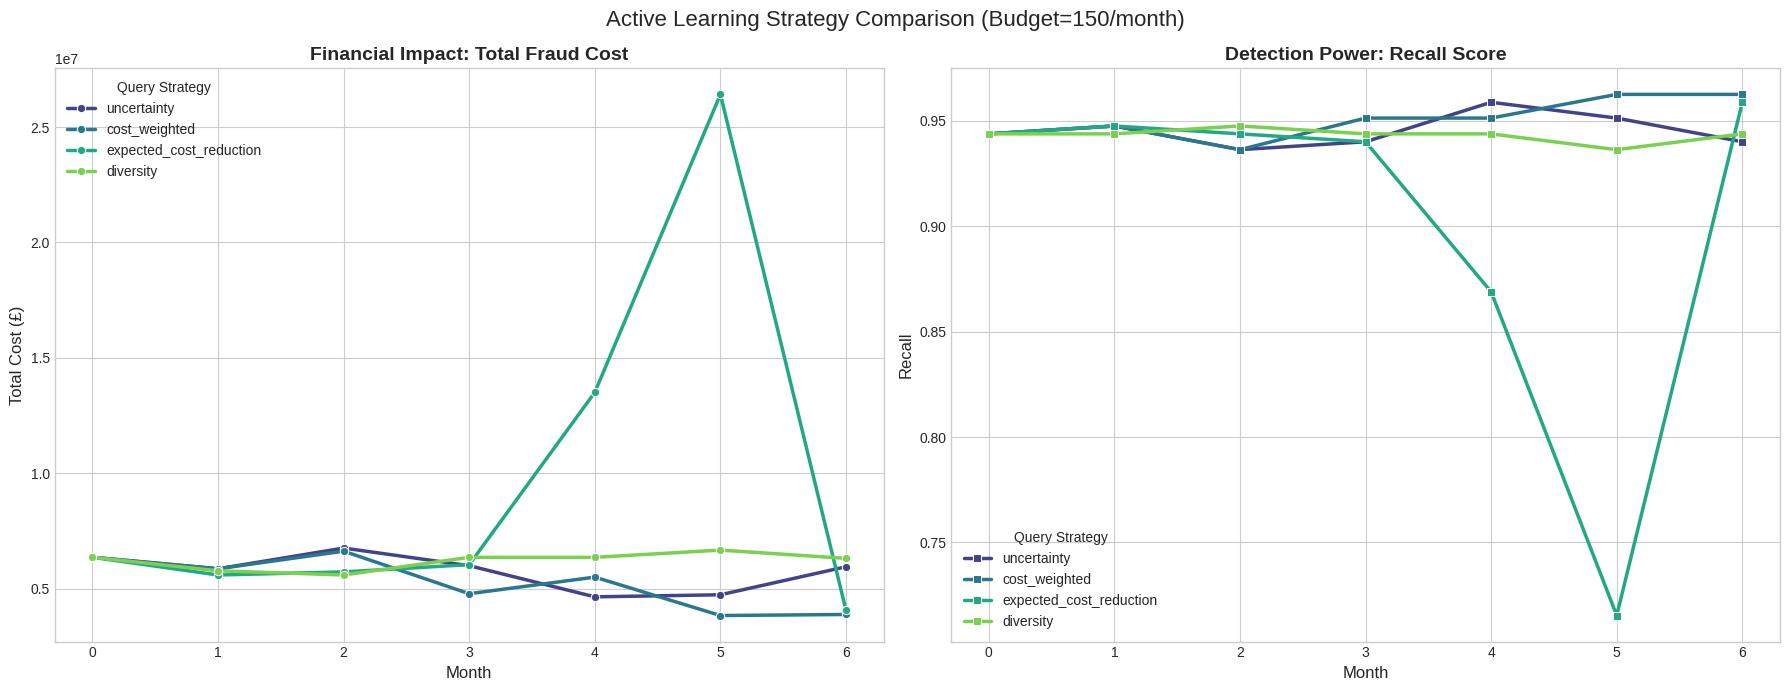


Final Cost Comparison (Month 6):
  cost_weighted            : £3,873,700 (Saved: £2,478,800)
  expected_cost_reduction  : £4,054,100 (Saved: £2,298,400)
  uncertainty              : £5,943,100 (Saved: £409,400)
  diversity                : £6,306,100 (Saved: £46,400)


In [ ]:
# =============================================================================
# 1. SETUP & DATA LOADING
# =============================================================================
import zipfile
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.cluster import MiniBatchKMeans
from sklearn.metrics import pairwise_distances_argmin_min
import warnings

warnings.filterwarnings('ignore') # Clean output

# ---- PATHS ----
ZIP_PATH = "/content/data_5L_new.zip"
EXTRACT_DIR = "/content/extracted_zip"

# ---- UNZIP & LOAD ----
if not os.path.exists(EXTRACT_DIR):
    with zipfile.ZipFile(ZIP_PATH, 'r') as z:
        z.extractall(EXTRACT_DIR)

csv_file = None
for file in os.listdir(EXTRACT_DIR):
    if file.endswith(".csv"):
        csv_file = os.path.join(EXTRACT_DIR, file)
        break

if csv_file is None:
    raise FileNotFoundError("No CSV file found inside the ZIP.")

print("Loading dataset...")
df = pd.read_csv(csv_file)
print(f"Data loaded: {df.shape}")

# =============================================================================
# 2. FRAUD RULES & HELPER FUNCTIONS
# =============================================================================

def apply_fraud_rules(df):
    """Industry-standard fraud detection rules."""
    flags = pd.Series(False, index=df.index)
    claim_ratio = df['sum_insured'] / (df['premium_with_tax'] + 1)
    coverage_ratio = df['sum_insured'] / (df['property_market_value'] + 1)

    flags |= (claim_ratio > 1500) & (df['previous_insurance_buildings'] == 0) & (df['no_of_claims_5yr'] > 0)
    flags |= (df['accidental_damage_premium'] > 0) & (df['unoccupied_days'] >= 30) & (df['no_of_claims_5yr'] > 0)
    flags |= (df['no_of_claims_5yr'] >= 3)
    flags |= (df['unoccupied_days'] >= 30) & (df['business_use'] == 'Y') & (df['no_of_claims_5yr'] > 0)
    flags |= (coverage_ratio > 0.8) & (df['no_of_claims_5yr'] > 0)
    flags |= (df['additional_coverage_amount'] >= 15000) & (df['no_of_claims_5yr'] > 0)
    flags |= (df['premium_payment_behaviour'] < 70) & (df['no_of_claims_5yr'] >= 2)
    flags |= (df['short_term_letting'] == 1) & (df['no_of_claims_5yr'] >= 2)
    return flags

def prepare_features(df, categorical_cols=None):
    if categorical_cols is None:
        categorical_cols = ['cust_occupation', 'owner_details', 'property_type',
                          'construction_material', 'roof_material', 'urban_rural', 'policy_product', 'business_use']
    df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)
    exclude_cols = ['fraud_label', 'fraud_probability', 'policy_no', 'unoccupied_reason']
    feature_cols = [col for col in df_encoded.columns if col not in exclude_cols]
    return df_encoded[feature_cols]

def calculate_costs(sum_insured, y_true, y_pred):
    costs = np.zeros(len(y_true))
    fn_mask = (y_true == 1) & (y_pred == 0)
    fp_mask = (y_true == 0) & (y_pred == 1)
    costs[fn_mask] = sum_insured[fn_mask] * 0.90 # FN Cost: Payout
    costs[fp_mask] = 100 # FP Cost: Investigation fee
    return costs

def evaluate_cost_sensitive(y_true, y_pred, sum_insured):
    costs = calculate_costs(sum_insured, y_true, y_pred)
    tp = np.sum((y_true == 1) & (y_pred == 1))
    fn_count = np.sum((y_true == 1) & (y_pred == 0))
    fp_count = np.sum((y_true == 0) & (y_pred == 1))
    recall = tp / (tp + fn_count) if (tp + fn_count) > 0 else 0
    return {'total_cost': np.sum(costs), 'recall': recall}

def find_optimal_threshold(model, X, y, sum_insured):
    proba = model.predict_proba(X)[:, 1]
    thresholds = np.linspace(0.1, 0.9, 50)
    best_cost = float('inf')
    best_thresh = 0.5
    for thresh in thresholds:
        y_pred = (proba >= thresh).astype(int)
        cost = np.sum(calculate_costs(sum_insured, y, y_pred))
        if cost < best_cost:
            best_cost = cost
            best_thresh = thresh
    return best_thresh

# =============================================================================
# 3. ADVANCED ACTIVE LEARNING CLASS
# =============================================================================

class ActiveLearningAgent:
    def __init__(self):
        self.model = XGBClassifier(
            n_estimators=100, max_depth=6, learning_rate=0.1,
            scale_pos_weight=5, random_state=42, eval_metric='logloss', n_jobs=-1
        )
        self.scaler = StandardScaler()
        self.threshold = 0.5
        self.labeled_data = {'X': None, 'y': None, 'sum_insured': None}
        self.feature_names = None

    def _align(self, df_input):
        X_feat = prepare_features(df_input.copy())
        for col in self.feature_names:
            if col not in X_feat.columns: X_feat[col] = 0
        return X_feat[self.feature_names].values

    def initial_train(self, df_universe, flagged_indices):
        investigated = df_universe.loc[flagged_indices]
        X_df = prepare_features(investigated.copy())
        self.feature_names = X_df.columns.tolist()

        X = X_df.values
        y = investigated['fraud_label'].values
        s = investigated['sum_insured'].values

        X_scaled = self.scaler.fit_transform(X)
        self.labeled_data = {'X': X_scaled, 'y': y, 'sum_insured': s}

        self.model.fit(X_scaled, y)
        self.threshold = find_optimal_threshold(self.model, X_scaled, y, s)

    def query(self, df_pool, budget, strategy):
        X_pool = self._align(df_pool)
        X_scaled = self.scaler.transform(X_pool)
        y_proba = self.model.predict_proba(X_scaled)[:, 1]
        sum_insured = df_pool['sum_insured'].values
        indices = df_pool.index.tolist()

        if strategy == 'uncertainty':
            # Closest to 0.5
            scores = np.abs(y_proba - 0.5)
            selected_idx = [indices[i] for i in np.argsort(scores)[:budget]]

        elif strategy == 'cost_weighted':
            # Uncertainty * Normalized Cost
            uncertainty = 0.5 - np.abs(y_proba - 0.5)
            norm_cost = sum_insured / (np.max(sum_insured) + 1)
            scores = uncertainty * norm_cost
            selected_idx = [indices[i] for i in np.argsort(scores)[::-1][:budget]]

        elif strategy == 'expected_cost_reduction':
            # Current Expected Risk
            risk_if_0 = y_proba * (sum_insured * 0.90) # False negative
            risk_if_1 = (1 - y_proba) * 100 # False positive
            # If we predict 0 (legit), risk is missing fraud. If 1 (fraud), risk is false alarm.
            current_risk = np.where(y_proba < self.threshold, risk_if_0, risk_if_1)
            selected_idx = [indices[i] for i in np.argsort(current_risk)[::-1][:budget]]

        elif strategy == 'diversity':
            # K-Means Centroids
            kmeans = MiniBatchKMeans(n_clusters=budget, random_state=42, batch_size=256)
            kmeans.fit(X_scaled)
            closest, _ = pairwise_distances_argmin_min(kmeans.cluster_centers_, X_scaled)
            selected_idx = [indices[i] for i in closest]

        return selected_idx

    def retrain(self, df_universe, new_indices):
        new_data = df_universe.loc[new_indices]
        X_new = self.scaler.transform(self._align(new_data))
        y_new = new_data['fraud_label'].values
        s_new = new_data['sum_insured'].values

        self.labeled_data['X'] = np.vstack([self.labeled_data['X'], X_new])
        self.labeled_data['y'] = np.concatenate([self.labeled_data['y'], y_new])
        self.labeled_data['sum_insured'] = np.concatenate([self.labeled_data['sum_insured'], s_new])

        self.model.fit(self.labeled_data['X'], self.labeled_data['y'])
        self.threshold = find_optimal_threshold(
            self.model, self.labeled_data['X'], self.labeled_data['y'], self.labeled_data['sum_insured']
        )

    def evaluate(self, df_test):
        X_test = self.scaler.transform(self._align(df_test))
        y_test = df_test['fraud_label'].values
        s_test = df_test['sum_insured'].values
        y_pred = (self.model.predict_proba(X_test)[:, 1] >= self.threshold).astype(int)
        return evaluate_cost_sensitive(y_test, y_pred, s_test)

# =============================================================================
# 4. COMPARATIVE SIMULATION LOOP
# =============================================================================

def run_comparison(df, strategies, n_months=6, monthly_vol=1000, budget=200):
    # 1. Common Pre-processing for Fairness
    # All strategies must start with the exact same flagged transactions
    initial_pool = df.sample(n=10000, random_state=42)
    flags = apply_fraud_rules(initial_pool)
    flagged_idx = initial_pool[flags].index

    # Common Test Set
    avail_after_init = df.drop(index=initial_pool.index)
    test_set = avail_after_init.sample(n=5000, random_state=999)

    # Track used indices for the simulation stream
    base_used_indices = set(initial_pool.index) | set(test_set.index)

    all_results = []

    print(f"{'='*80}")
    print(f"STARTING COMPARISON OF {len(strategies)} STRATEGIES")
    print(f"{'='*80}")

    for strat in strategies:
        print(f"\n>> Running Strategy: {strat.upper()}")

        # Reset Agent
        agent = ActiveLearningAgent()
        agent.initial_train(df, flagged_idx)

        # Local copy of used indices for this run
        current_used_indices = base_used_indices.copy()

        # Baseline
        base_metrics = agent.evaluate(test_set)
        all_results.append({
            'Strategy': strat, 'Month': 0,
            'Cost': base_metrics['total_cost'], 'Recall': base_metrics['recall']
        })

        for month in range(1, n_months + 1):
            # Ensure every strategy gets the SAME batch of new customers
            available = df.drop(index=current_used_indices)
            if len(available) < monthly_vol: break

            # Seed = month ensures consistent batches across strategies
            new_batch = available.sample(n=monthly_vol, random_state=month)
            current_used_indices.update(new_batch.index)

            # Unique Query Logic
            query_idx = agent.query(new_batch, budget, strat)

            # Retrain
            agent.retrain(df, query_idx)

            # Evaluate
            metrics = agent.evaluate(test_set)
            all_results.append({
                'Strategy': strat, 'Month': month,
                'Cost': metrics['total_cost'], 'Recall': metrics['recall']
            })

    return pd.DataFrame(all_results)

# =============================================================================
# 5. EXECUTE & VISUALIZE
# =============================================================================

STRATEGIES_TO_TEST = [
    'uncertainty',
    'cost_weighted',
    'expected_cost_reduction',
    'diversity'
]

# Run Simulation
df_results = run_comparison(
    df,
    strategies=STRATEGIES_TO_TEST,
    n_months=6,
    monthly_vol=1000,
    budget=150
)

# ---- PLOTTING ----
plt.style.use('seaborn-v0_8-whitegrid')
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# 1. Total Cost
sns.lineplot(data=df_results, x='Month', y='Cost', hue='Strategy',
             marker='o', linewidth=2.5, ax=axes[0], palette='viridis')
axes[0].set_title('Financial Impact: Total Fraud Cost', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Total Cost (£)', fontsize=12)
axes[0].set_xlabel('Month', fontsize=12)
axes[0].legend(title='Query Strategy')

# 2. Recall
sns.lineplot(data=df_results, x='Month', y='Recall', hue='Strategy',
             marker='s', linewidth=2.5, ax=axes[1], palette='viridis')
axes[1].set_title('Detection Power: Recall Score', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Recall', fontsize=12)
axes[1].set_xlabel('Month', fontsize=12)
axes[1].legend(title='Query Strategy')

plt.suptitle(f'Active Learning Strategy Comparison (Budget={150}/month)', fontsize=16)
plt.tight_layout()
plt.show()

# ---- SUMMARY TABLE ----
pivot_cost = df_results.pivot(index='Strategy', columns='Month', values='Cost')
pivot_recall = df_results.pivot(index='Strategy', columns='Month', values='Recall')

print("\nFinal Cost Comparison (Month 6):")
final_costs = pivot_cost[6].sort_values()
baseline_cost = pivot_cost[0].mean()
for strat, cost in final_costs.items():
    saving = baseline_cost - cost
    print(f"  {strat.ljust(25)}: £{cost:,.0f} (Saved: £{saving:,.0f})")

## Various scenarios comparison

Loading dataset...
Data loaded: (500000, 50)
STARTING MULTI-SCENARIO SIMULATION (9 Scenarios)
Strategies: ['uncertainty', 'cost_weighted', 'expected_cost_reduction', 'diversity']

>> Processing: 1. Low Vol / Low Bud

>> Processing: 2. Low Vol / Med Bud

>> Processing: 3. Low Vol / High Bud

>> Processing: 4. Med Vol / Low Bud

>> Processing: 5. Med Vol / Med Bud

>> Processing: 6. Med Vol / High Bud

>> Processing: 7. High Vol / Low Bud

>> Processing: 8. High Vol / Med Bud

>> Processing: 9. High Vol / High Bud


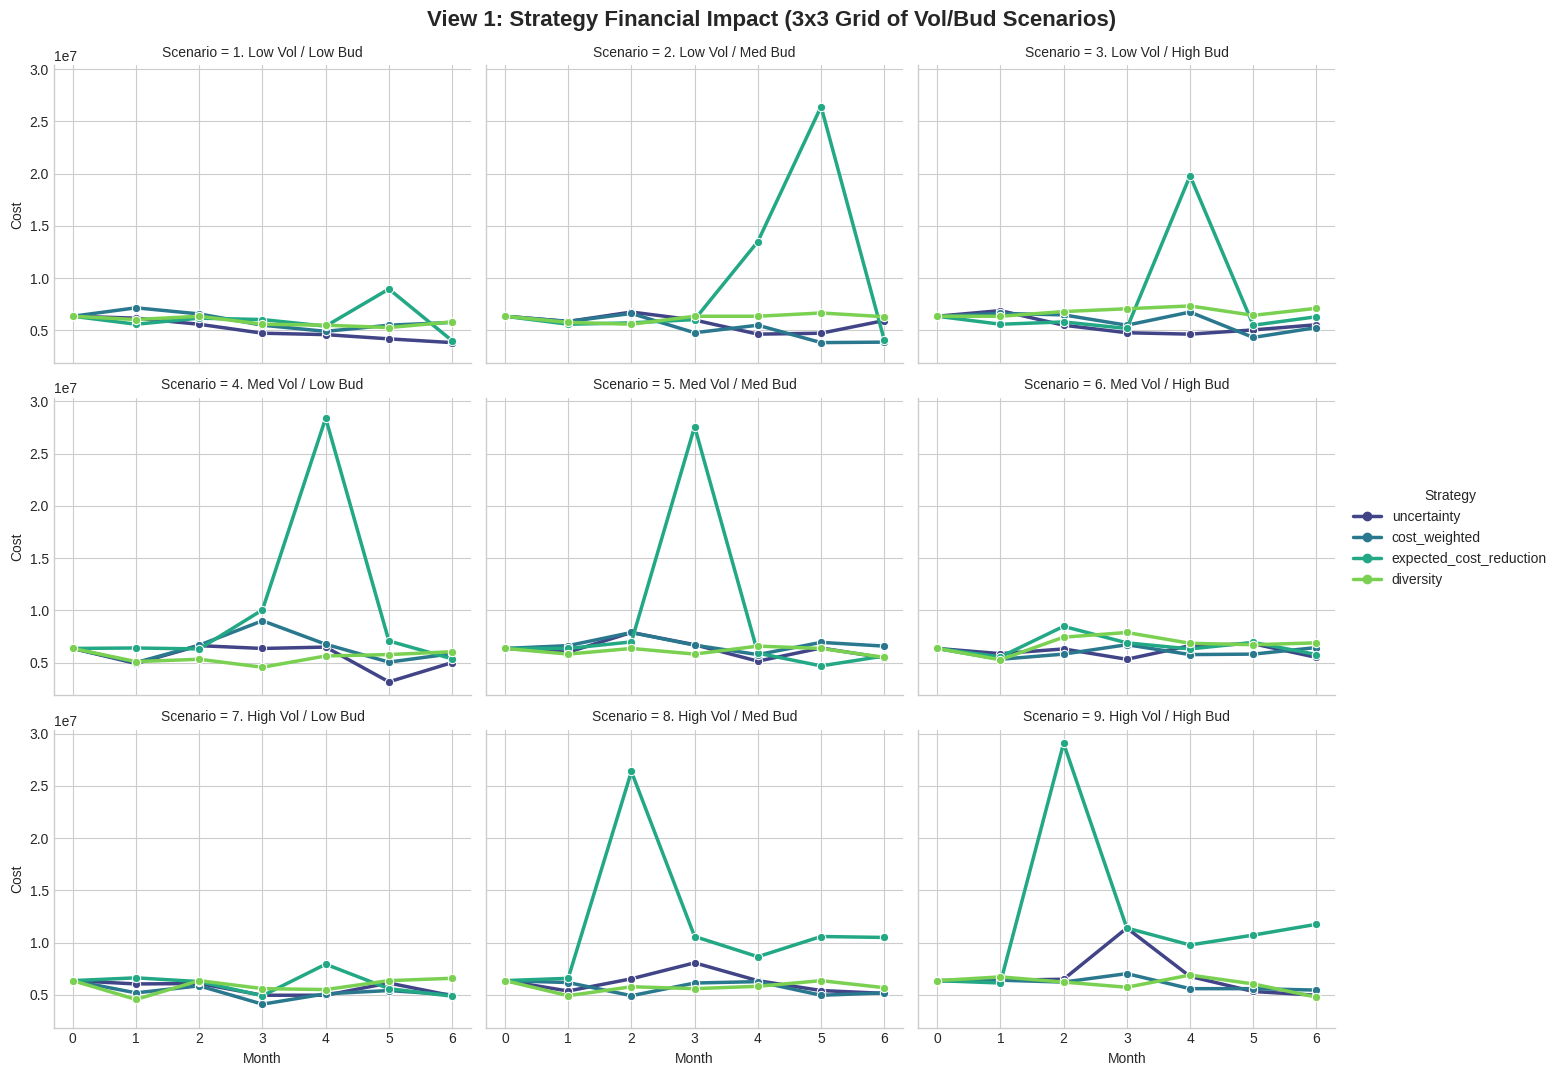

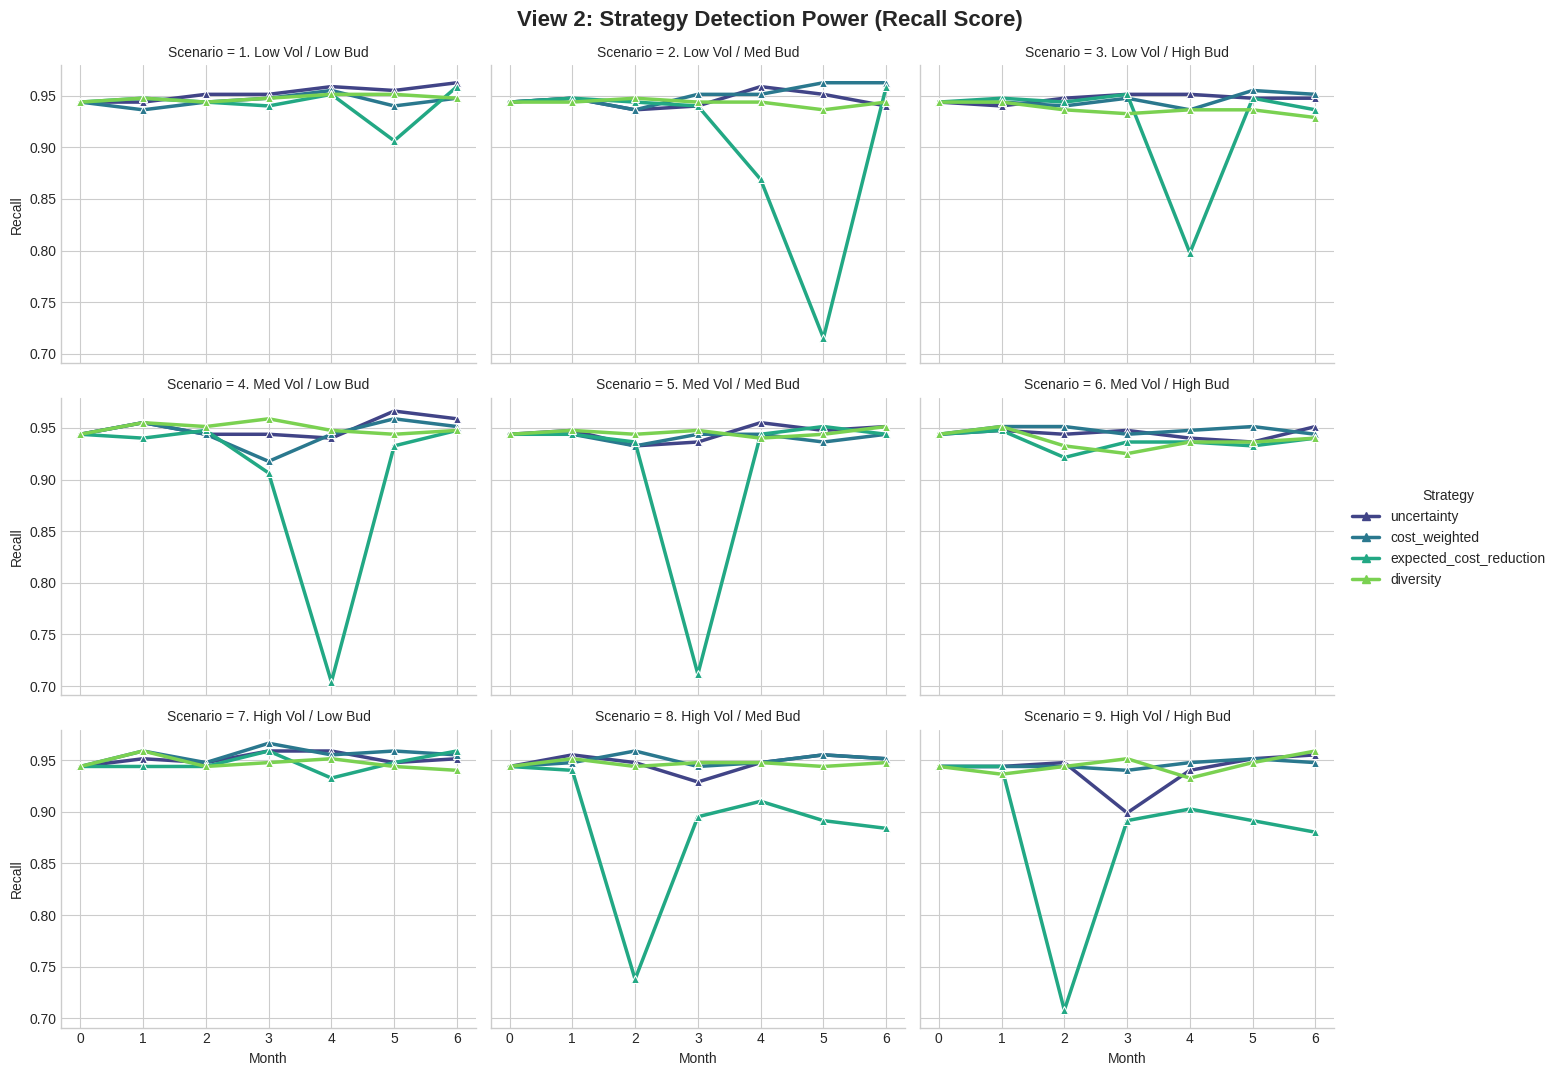

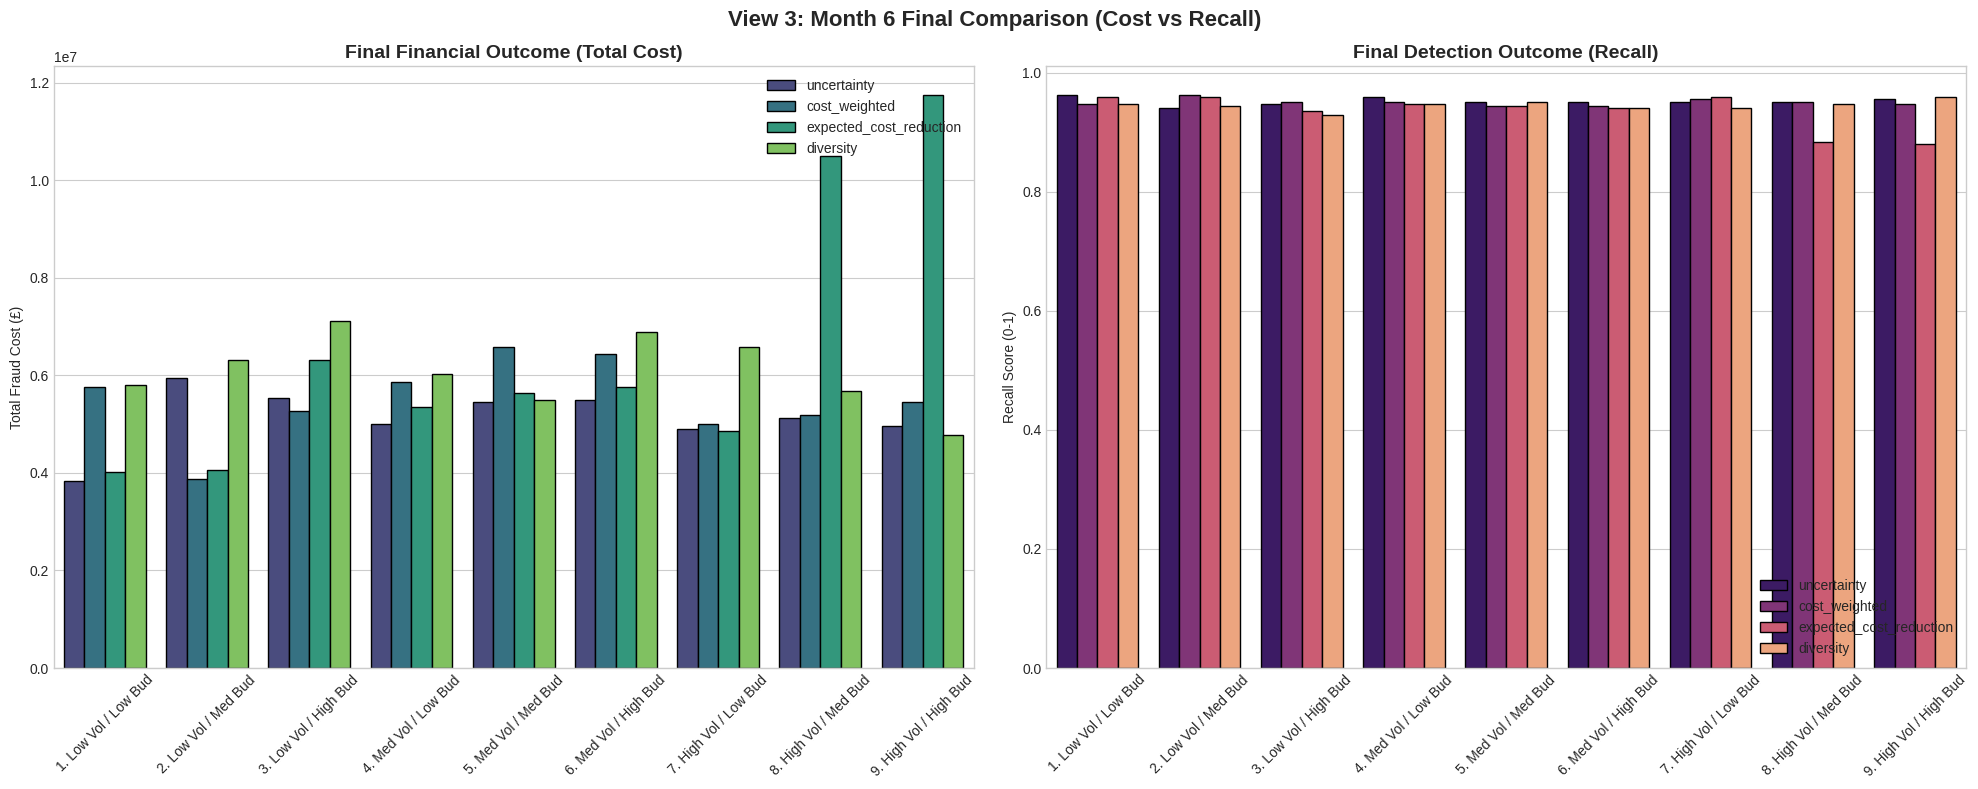


FINAL COST SUMMARY (Month 6)
Scenario                1. Low Vol / Low Bud 2. Low Vol / Med Bud  \
Strategy                                                            
cost_weighted                     £5,763,500           £3,873,700   
diversity                         £5,811,600           £6,306,100   
expected_cost_reduction           £4,009,100           £4,054,100   
uncertainty                       £3,828,600           £5,943,100   

Scenario                3. Low Vol / High Bud 4. Med Vol / Low Bud  \
Strategy                                                             
cost_weighted                      £5,268,600           £5,853,500   
diversity                          £7,113,300           £6,036,000   
expected_cost_reduction            £6,304,300           £5,358,200   
uncertainty                        £5,538,800           £4,998,900   

Scenario                5. Med Vol / Med Bud 6. Med Vol / High Bud  \
Strategy                                                        

In [ ]:
# =============================================================================
# 1. SETUP & DATA LOADING
# =============================================================================
import zipfile
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier
from sklearn.cluster import MiniBatchKMeans
from sklearn.metrics import pairwise_distances_argmin_min
import warnings

warnings.filterwarnings('ignore')

# ---- PATHS ----
ZIP_PATH = "/content/data_5L_new.zip"
EXTRACT_DIR = "/content/extracted_zip"

# ---- UNZIP & LOAD ----
if not os.path.exists(EXTRACT_DIR):
    with zipfile.ZipFile(ZIP_PATH, 'r') as z:
        z.extractall(EXTRACT_DIR)

csv_file = None
for file in os.listdir(EXTRACT_DIR):
    if file.endswith(".csv"):
        csv_file = os.path.join(EXTRACT_DIR, file)
        break

if csv_file is None:
    raise FileNotFoundError("No CSV file found inside the ZIP.")

print("Loading dataset...")
df = pd.read_csv(csv_file)
print(f"Data loaded: {df.shape}")

# =============================================================================
# 2. FRAUD RULES & HELPER FUNCTIONS
# =============================================================================

def apply_fraud_rules(df):
    """Industry-standard fraud detection rules."""
    flags = pd.Series(False, index=df.index)
    claim_ratio = df['sum_insured'] / (df['premium_with_tax'] + 1)
    coverage_ratio = df['sum_insured'] / (df['property_market_value'] + 1)

    flags |= (claim_ratio > 1500) & (df['previous_insurance_buildings'] == 0) & (df['no_of_claims_5yr'] > 0)
    flags |= (df['accidental_damage_premium'] > 0) & (df['unoccupied_days'] >= 30) & (df['no_of_claims_5yr'] > 0)
    flags |= (df['no_of_claims_5yr'] >= 3)
    flags |= (df['unoccupied_days'] >= 30) & (df['business_use'] == 'Y') & (df['no_of_claims_5yr'] > 0)
    flags |= (coverage_ratio > 0.8) & (df['no_of_claims_5yr'] > 0)
    flags |= (df['additional_coverage_amount'] >= 15000) & (df['no_of_claims_5yr'] > 0)
    flags |= (df['premium_payment_behaviour'] < 70) & (df['no_of_claims_5yr'] >= 2)
    flags |= (df['short_term_letting'] == 1) & (df['no_of_claims_5yr'] >= 2)
    return flags

def prepare_features(df, categorical_cols=None):
    if categorical_cols is None:
        categorical_cols = ['cust_occupation', 'owner_details', 'property_type',
                          'construction_material', 'roof_material', 'urban_rural', 'policy_product', 'business_use']
    df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)
    exclude_cols = ['fraud_label', 'fraud_probability', 'policy_no', 'unoccupied_reason']
    feature_cols = [col for col in df_encoded.columns if col not in exclude_cols]
    return df_encoded[feature_cols]

def calculate_costs(sum_insured, y_true, y_pred):
    costs = np.zeros(len(y_true))
    fn_mask = (y_true == 1) & (y_pred == 0)
    fp_mask = (y_true == 0) & (y_pred == 1)
    costs[fn_mask] = sum_insured[fn_mask] * 0.90 # FN Cost: Payout
    costs[fp_mask] = 100 # FP Cost: Investigation fee
    return costs

def evaluate_cost_sensitive(y_true, y_pred, sum_insured):
    costs = calculate_costs(sum_insured, y_true, y_pred)
    tp = np.sum((y_true == 1) & (y_pred == 1))
    fn_count = np.sum((y_true == 1) & (y_pred == 0))
    fp_count = np.sum((y_true == 0) & (y_pred == 1))
    recall = tp / (tp + fn_count) if (tp + fn_count) > 0 else 0
    return {'total_cost': np.sum(costs), 'recall': recall}

def find_optimal_threshold(model, X, y, sum_insured):
    proba = model.predict_proba(X)[:, 1]
    thresholds = np.linspace(0.1, 0.9, 50)
    best_cost = float('inf')
    best_thresh = 0.5
    for thresh in thresholds:
        y_pred = (proba >= thresh).astype(int)
        cost = np.sum(calculate_costs(sum_insured, y, y_pred))
        if cost < best_cost:
            best_cost = cost
            best_thresh = thresh
    return best_thresh

# =============================================================================
# 3. ADVANCED ACTIVE LEARNING CLASS
# =============================================================================

class ActiveLearningAgent:
    def __init__(self):
        self.model = XGBClassifier(
            n_estimators=100, max_depth=6, learning_rate=0.1,
            scale_pos_weight=5, random_state=42, eval_metric='logloss', n_jobs=-1
        )
        self.scaler = StandardScaler()
        self.threshold = 0.5
        self.labeled_data = {'X': None, 'y': None, 'sum_insured': None}
        self.feature_names = None

    def _align(self, df_input):
        X_feat = prepare_features(df_input.copy())
        for col in self.feature_names:
            if col not in X_feat.columns: X_feat[col] = 0
        return X_feat[self.feature_names].values

    def initial_train(self, df_universe, flagged_indices):
        investigated = df_universe.loc[flagged_indices]
        X_df = prepare_features(investigated.copy())
        self.feature_names = X_df.columns.tolist()

        X = X_df.values
        y = investigated['fraud_label'].values
        s = investigated['sum_insured'].values

        X_scaled = self.scaler.fit_transform(X)
        self.labeled_data = {'X': X_scaled, 'y': y, 'sum_insured': s}

        self.model.fit(X_scaled, y)
        self.threshold = find_optimal_threshold(self.model, X_scaled, y, s)

    def query(self, df_pool, budget, strategy):
        X_pool = self._align(df_pool)
        X_scaled = self.scaler.transform(X_pool)
        y_proba = self.model.predict_proba(X_scaled)[:, 1]
        sum_insured = df_pool['sum_insured'].values
        indices = df_pool.index.tolist()

        if strategy == 'uncertainty':
            scores = np.abs(y_proba - 0.5)
            selected_idx = [indices[i] for i in np.argsort(scores)[:budget]]

        elif strategy == 'cost_weighted':
            uncertainty = 0.5 - np.abs(y_proba - 0.5)
            norm_cost = sum_insured / (np.max(sum_insured) + 1)
            scores = uncertainty * norm_cost
            selected_idx = [indices[i] for i in np.argsort(scores)[::-1][:budget]]

        elif strategy == 'expected_cost_reduction':
            risk_if_0 = y_proba * (sum_insured * 0.90)
            risk_if_1 = (1 - y_proba) * 100
            current_risk = np.where(y_proba < self.threshold, risk_if_0, risk_if_1)
            selected_idx = [indices[i] for i in np.argsort(current_risk)[::-1][:budget]]

        elif strategy == 'diversity':
            kmeans = MiniBatchKMeans(n_clusters=budget, random_state=42, batch_size=256)
            kmeans.fit(X_scaled)
            closest, _ = pairwise_distances_argmin_min(kmeans.cluster_centers_, X_scaled)
            selected_idx = [indices[i] for i in closest]

        return selected_idx

    def retrain(self, df_universe, new_indices):
        new_data = df_universe.loc[new_indices]
        X_new = self.scaler.transform(self._align(new_data))
        y_new = new_data['fraud_label'].values
        s_new = new_data['sum_insured'].values

        self.labeled_data['X'] = np.vstack([self.labeled_data['X'], X_new])
        self.labeled_data['y'] = np.concatenate([self.labeled_data['y'], y_new])
        self.labeled_data['sum_insured'] = np.concatenate([self.labeled_data['sum_insured'], s_new])

        self.model.fit(self.labeled_data['X'], self.labeled_data['y'])
        self.threshold = find_optimal_threshold(
            self.model, self.labeled_data['X'], self.labeled_data['y'], self.labeled_data['sum_insured']
        )

    def evaluate(self, df_test):
        X_test = self.scaler.transform(self._align(df_test))
        y_test = df_test['fraud_label'].values
        s_test = df_test['sum_insured'].values
        y_pred = (self.model.predict_proba(X_test)[:, 1] >= self.threshold).astype(int)
        return evaluate_cost_sensitive(y_test, y_pred, s_test)

# =============================================================================
# 4. SCENARIO SIMULATION LOOP
# =============================================================================

def run_multi_scenario_comparison(df, strategies, scenarios, n_months=6):
    """
    Runs the AL loop for multiple strategies across multiple scenarios (Vol/Budget combos).
    """
    # 1. Common Initialization
    initial_pool = df.sample(n=10000, random_state=42)
    flags = apply_fraud_rules(initial_pool)
    flagged_idx = initial_pool[flags].index

    # Common Test Set
    avail_after_init = df.drop(index=initial_pool.index)
    test_set = avail_after_init.sample(n=5000, random_state=999)
    base_used_indices = set(initial_pool.index) | set(test_set.index)

    all_results = []

    print(f"{'='*80}")
    print(f"STARTING MULTI-SCENARIO SIMULATION ({len(scenarios)} Scenarios)")
    print(f"Strategies: {strategies}")
    print(f"{'='*80}")

    for scenario in scenarios:
        scen_name = scenario['name']
        monthly_vol = scenario['vol']
        budget = scenario['budget']

        print(f"\n>> Processing: {scen_name}")

        for strat in strategies:
            # Reset Agent
            agent = ActiveLearningAgent()
            agent.initial_train(df, flagged_idx)

            # Local copy of used indices for this run
            current_used_indices = base_used_indices.copy()

            # Baseline (Month 0)
            base_metrics = agent.evaluate(test_set)
            all_results.append({
                'Scenario': scen_name,
                'Strategy': strat,
                'Month': 0,
                'Cost': base_metrics['total_cost'],
                'Recall': base_metrics['recall']
            })

            # Simulation Loop
            for month in range(1, n_months + 1):
                # Ensure every strategy/scenario gets the SAME batch for specific month
                available = df.drop(index=current_used_indices)
                if len(available) < monthly_vol: break

                # Seed = month + scenario_vol ensures consistency
                new_batch = available.sample(n=monthly_vol, random_state=month)
                current_used_indices.update(new_batch.index)

                # Query
                query_idx = agent.query(new_batch, budget, strat)

                # Retrain
                agent.retrain(df, query_idx)

                # Evaluate
                metrics = agent.evaluate(test_set)
                all_results.append({
                    'Scenario': scen_name,
                    'Strategy': strat,
                    'Month': month,
                    'Cost': metrics['total_cost'],
                    'Recall': metrics['recall']
                })

    return pd.DataFrame(all_results)

# =============================================================================
# 5. EXECUTION & VISUALIZATION
# =============================================================================

# ---- CONFIGURATION ----
STRATEGIES_TO_TEST = ['uncertainty', 'cost_weighted', 'expected_cost_reduction', 'diversity']

# Define 9 Scenarios (3 Volumes x 3 Budgets)
SCENARIOS = [
    # --- LOW VOLUME (1000) ---
    {'name': '1. Low Vol / Low Bud',   'vol': 1000, 'budget': 50},
    {'name': '2. Low Vol / Med Bud',   'vol': 1000, 'budget': 150},
    {'name': '3. Low Vol / High Bud',  'vol': 1000, 'budget': 300},

    # --- MED VOLUME (1500) ---
    {'name': '4. Med Vol / Low Bud',   'vol': 1500, 'budget': 50},
    {'name': '5. Med Vol / Med Bud',   'vol': 1500, 'budget': 150},
    {'name': '6. Med Vol / High Bud',  'vol': 1500, 'budget': 300},

    # --- HIGH VOLUME (2000) ---
    {'name': '7. High Vol / Low Bud',  'vol': 2000, 'budget': 50},
    {'name': '8. High Vol / Med Bud',  'vol': 2000, 'budget': 150},
    {'name': '9. High Vol / High Bud', 'vol': 2000, 'budget': 300},
]

# Run Simulation
df_results = run_multi_scenario_comparison(
    df,
    strategies=STRATEGIES_TO_TEST,
    scenarios=SCENARIOS,
    n_months=6
)

# ---- PLOTTING ----
plt.style.use('seaborn-v0_8-whitegrid')

# VIEW 1: Strategy Performance (Facet by Scenario) - COST
# col_wrap=3 creates a nice 3x3 grid
g_cost = sns.relplot(
    data=df_results,
    x="Month", y="Cost",
    hue="Strategy",
    col="Scenario",
    col_wrap=3,   # Creates a 3x3 grid
    kind="line",
    marker="o", linewidth=2.5,
    palette='viridis',
    height=3.5, aspect=1.3
)
g_cost.fig.suptitle('View 1: Strategy Financial Impact (3x3 Grid of Vol/Bud Scenarios)', y=1.02, fontsize=16, fontweight='bold')
plt.show()

# VIEW 2: Strategy Performance (Facet by Scenario) - RECALL
g_rec = sns.relplot(
    data=df_results,
    x="Month", y="Recall",
    hue="Strategy",
    col="Scenario",
    col_wrap=3,  # Creates a 3x3 grid
    kind="line",
    marker="^", linewidth=2.5,
    palette='viridis',
    height=3.5, aspect=1.3
)
g_rec.fig.suptitle('View 2: Strategy Detection Power (Recall Score)', y=1.02, fontsize=16, fontweight='bold')
plt.show()

# VIEW 3: Final Month Summary (Side-by-Side Bar Charts)
final_month_data = df_results[df_results['Month'] == 6]
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# Plot Cost
sns.barplot(
    data=final_month_data, x='Scenario', y='Cost', hue='Strategy',
    palette='viridis', edgecolor='black', ax=axes[0]
)
axes[0].set_title("Final Financial Outcome (Total Cost)", fontsize=14, fontweight='bold')
axes[0].set_ylabel("Total Fraud Cost (£)")
axes[0].set_xlabel("")
axes[0].tick_params(axis='x', rotation=45) # Rotate labels to fit 9 items
axes[0].legend(loc='upper right')

# Plot Recall
sns.barplot(
    data=final_month_data, x='Scenario', y='Recall', hue='Strategy',
    palette='magma', edgecolor='black', ax=axes[1]
)
axes[1].set_title("Final Detection Outcome (Recall)", fontsize=14, fontweight='bold')
axes[1].set_ylabel("Recall Score (0-1)")
axes[1].set_xlabel("")
axes[1].tick_params(axis='x', rotation=45) # Rotate labels
axes[1].legend(loc='lower right')

plt.suptitle("View 3: Month 6 Final Comparison (Cost vs Recall)", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# ---- TEXT SUMMARY ----
print("\n" + "="*50)
print("FINAL COST SUMMARY (Month 6)")
print("="*50)
pivot_cost = final_month_data.pivot(index='Strategy', columns='Scenario', values='Cost')
print(pivot_cost.applymap(lambda x: f"£{x:,.0f}"))

print("\n" + "="*50)
print("FINAL RECALL SUMMARY (Month 6)")
print("="*50)
pivot_recall = final_month_data.pivot(index='Strategy', columns='Scenario', values='Recall')
print(pivot_recall.applymap(lambda x: f"{x:.2%}"))

## 36-monthly duration

Loading dataset...
Data loaded: (500000, 50)
STARTING 36-MONTH SIMULATION (9 Scenarios)
Strategies: ['random', 'uncertainty', 'cost_weighted', 'expected_cost_reduction', 'diversity', 'high_confidence']

>> Processing: 1. Low Vol / Low Bud
   [high_confidence] Month 36 complete.
>> Processing: 2. Low Vol / Med Bud
   [high_confidence] Month 36 complete.
>> Processing: 3. Low Vol / High Bud
   [high_confidence] Month 36 complete.
>> Processing: 4. Med Vol / Low Bud
   [high_confidence] Month 36 complete.
>> Processing: 5. Med Vol / Med Bud
   [high_confidence] Month 36 complete.
>> Processing: 6. Med Vol / High Bud
   [high_confidence] Month 36 complete.
>> Processing: 7. High Vol / Low Bud
   [high_confidence] Month 36 complete.
>> Processing: 8. High Vol / Med Bud
   [high_confidence] Month 36 complete.
>> Processing: 9. High Vol / High Bud


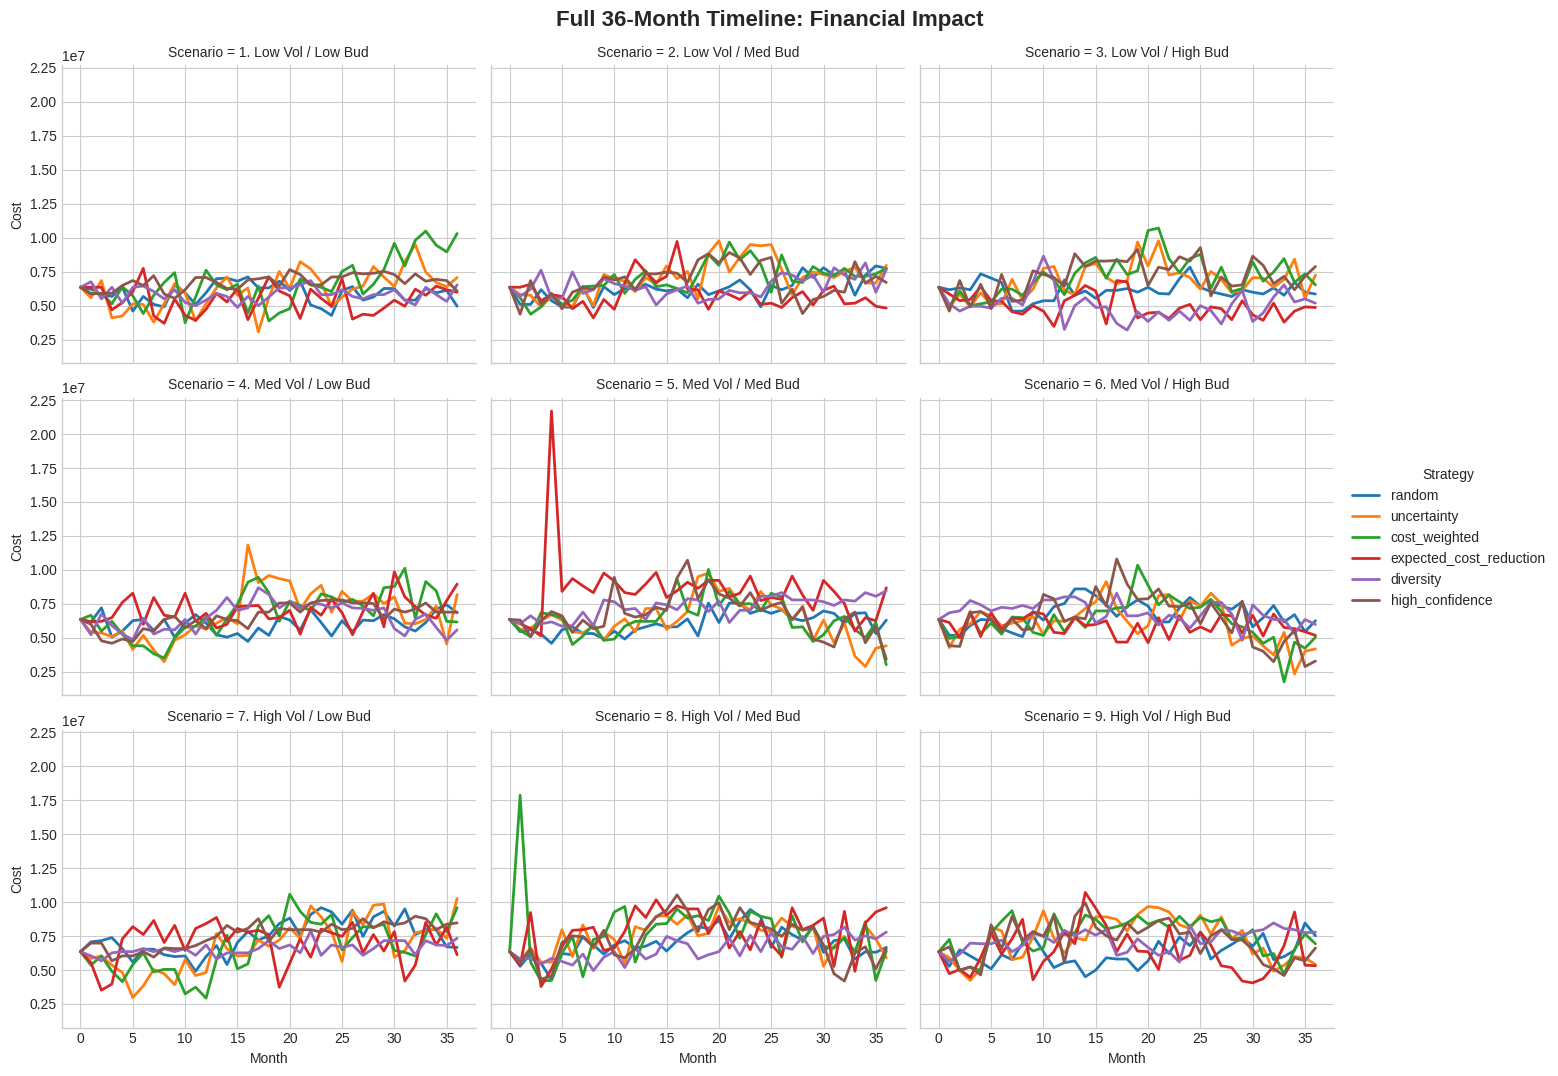

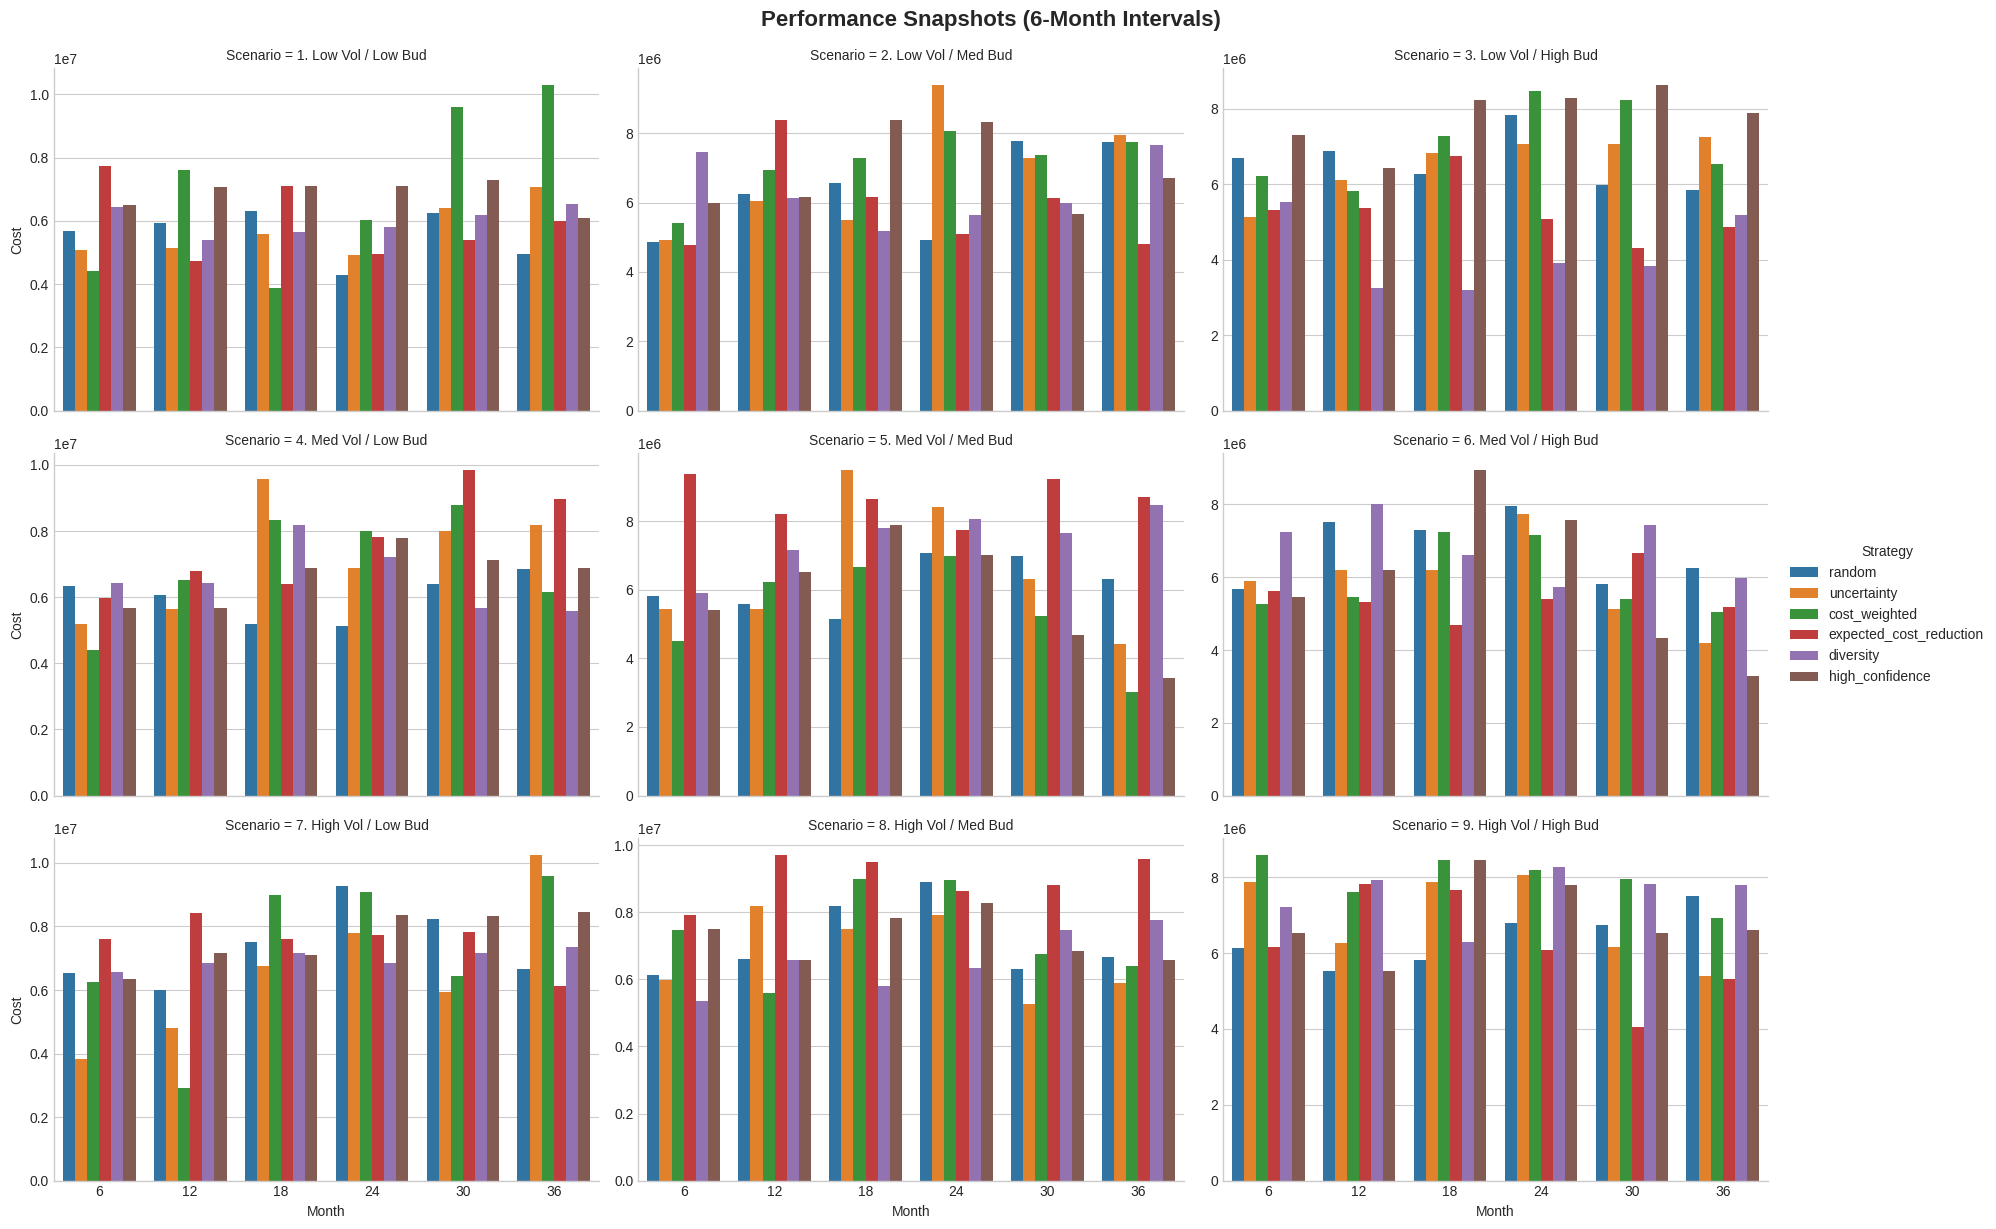


FINAL COST SUMMARY (Month 36)
Scenario                 1. Low Vol / Low Bud  2. Low Vol / Med Bud  \
Strategy                                                              
cost_weighted                      10,306,000             7,741,200   
diversity                           6,528,900             7,652,200   
expected_cost_reduction             5,987,100             4,817,700   
high_confidence                     6,076,800             6,706,200   
random                              4,954,400             7,742,800   
uncertainty                         7,066,000             7,966,100   

Scenario                 3. Low Vol / High Bud  4. Med Vol / Low Bud  \
Strategy                                                               
cost_weighted                        6,526,400             6,166,800   
diversity                            5,177,300             5,586,000   
expected_cost_reduction              4,862,300             8,956,100   
high_confidence                      7,8

In [ ]:
# =============================================================================
# 1. SETUP & DATA LOADING
# =============================================================================
import zipfile
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier
from sklearn.cluster import MiniBatchKMeans
from sklearn.metrics import pairwise_distances_argmin_min
import warnings

warnings.filterwarnings('ignore')

# ---- PATHS ----
# Ensure this matches your specific environment path
ZIP_PATH = "/content/data_5L_new.zip"
EXTRACT_DIR = "/content/extracted_zip"

# ---- UNZIP & LOAD ----
if not os.path.exists(EXTRACT_DIR):
    # Check if zip exists before trying to extract
    if os.path.exists(ZIP_PATH):
        with zipfile.ZipFile(ZIP_PATH, 'r') as z:
            z.extractall(EXTRACT_DIR)
    else:
        # Fallback for demonstration if file not found in local path
        print(f"Warning: {ZIP_PATH} not found. Ensure data is uploaded.")

csv_file = None
if os.path.exists(EXTRACT_DIR):
    for file in os.listdir(EXTRACT_DIR):
        if file.endswith(".csv"):
            csv_file = os.path.join(EXTRACT_DIR, file)
            break

if csv_file is None:
    # Gentle error handling if user hasn't uploaded data yet
    print("No CSV file found. Please upload data_5L_new.zip to Colab.")
else:
    print("Loading dataset...")
    df = pd.read_csv(csv_file)
    print(f"Data loaded: {df.shape}")

# =============================================================================
# 2. FRAUD RULES & HELPER FUNCTIONS
# =============================================================================

def apply_fraud_rules(df):
    """Industry-standard fraud detection rules."""
    flags = pd.Series(False, index=df.index)
    # Avoid division by zero
    claim_ratio = df['sum_insured'] / (df['premium_with_tax'] + 1)
    coverage_ratio = df['sum_insured'] / (df['property_market_value'] + 1)

    flags |= (claim_ratio > 1500) & (df['previous_insurance_buildings'] == 0) & (df['no_of_claims_5yr'] > 0)
    flags |= (df['accidental_damage_premium'] > 0) & (df['unoccupied_days'] >= 30) & (df['no_of_claims_5yr'] > 0)
    flags |= (df['no_of_claims_5yr'] >= 3)
    flags |= (df['unoccupied_days'] >= 30) & (df['business_use'] == 'Y') & (df['no_of_claims_5yr'] > 0)
    flags |= (coverage_ratio > 0.8) & (df['no_of_claims_5yr'] > 0)
    flags |= (df['additional_coverage_amount'] >= 15000) & (df['no_of_claims_5yr'] > 0)
    flags |= (df['premium_payment_behaviour'] < 70) & (df['no_of_claims_5yr'] >= 2)
    flags |= (df['short_term_letting'] == 1) & (df['no_of_claims_5yr'] >= 2)
    return flags

def prepare_features(df, categorical_cols=None):
    if categorical_cols is None:
        categorical_cols = ['cust_occupation', 'owner_details', 'property_type',
                           'construction_material', 'roof_material', 'urban_rural', 'policy_product', 'business_use']

    # Handle missing cols for robustness
    existing_cats = [c for c in categorical_cols if c in df.columns]

    df_encoded = pd.get_dummies(df, columns=existing_cats, drop_first=True)
    exclude_cols = ['fraud_label', 'fraud_probability', 'policy_no', 'unoccupied_reason']
    feature_cols = [col for col in df_encoded.columns if col not in exclude_cols]
    return df_encoded[feature_cols]

def calculate_costs(sum_insured, y_true, y_pred):
    costs = np.zeros(len(y_true))
    fn_mask = (y_true == 1) & (y_pred == 0)
    fp_mask = (y_true == 0) & (y_pred == 1)
    costs[fn_mask] = sum_insured[fn_mask] * 0.90 # FN Cost: Payout (Claim Amount)
    costs[fp_mask] = 100 # FP Cost: Investigation fee
    return costs

def evaluate_cost_sensitive(y_true, y_pred, sum_insured):
    costs = calculate_costs(sum_insured, y_true, y_pred)
    tp = np.sum((y_true == 1) & (y_pred == 1))
    fn_count = np.sum((y_true == 1) & (y_pred == 0))
    # Avoid division by zero
    recall = tp / (tp + fn_count) if (tp + fn_count) > 0 else 0
    return {'total_cost': np.sum(costs), 'recall': recall}

def find_optimal_threshold(model, X, y, sum_insured):
    proba = model.predict_proba(X)[:, 1]
    thresholds = np.linspace(0.1, 0.9, 50)
    best_cost = float('inf')
    best_thresh = 0.5

    for thresh in thresholds:
        y_pred = (proba >= thresh).astype(int)
        cost = np.sum(calculate_costs(sum_insured, y, y_pred))
        if cost < best_cost:
            best_cost = cost
            best_thresh = thresh
    return best_thresh

# =============================================================================
# 3. ADVANCED ACTIVE LEARNING CLASS (UPDATED)
# =============================================================================

class ActiveLearningAgent:
    def __init__(self):
        self.model = XGBClassifier(
            n_estimators=100, max_depth=6, learning_rate=0.1,
            scale_pos_weight=5, random_state=42, eval_metric='logloss', n_jobs=-1
        )
        self.scaler = StandardScaler()
        self.threshold = 0.5
        self.labeled_data = {'X': None, 'y': None, 'sum_insured': None}
        self.feature_names = None

    def _align(self, df_input):
        X_feat = prepare_features(df_input.copy())
        # Ensure all columns match training data
        for col in self.feature_names:
            if col not in X_feat.columns: X_feat[col] = 0
        return X_feat[self.feature_names].values

    def initial_train(self, df_universe, flagged_indices):
        investigated = df_universe.loc[flagged_indices]
        X_df = prepare_features(investigated.copy())
        self.feature_names = X_df.columns.tolist()

        X = X_df.values
        y = investigated['fraud_label'].values
        s = investigated['sum_insured'].values

        X_scaled = self.scaler.fit_transform(X)
        self.labeled_data = {'X': X_scaled, 'y': y, 'sum_insured': s}

        self.model.fit(X_scaled, y)
        self.threshold = find_optimal_threshold(self.model, X_scaled, y, s)

    def query(self, df_pool, budget, strategy):
        X_pool = self._align(df_pool)
        X_scaled = self.scaler.transform(X_pool)
        y_proba = self.model.predict_proba(X_scaled)[:, 1]
        sum_insured = df_pool['sum_insured'].values
        indices = df_pool.index.tolist()

        selected_idx = []

        # --- 1. Uncertainty Sampling (Least Confidence) ---
        if strategy == 'uncertainty':
            scores = np.abs(y_proba - 0.5) # Lower is more uncertain
            # Sort by lowest score
            selected_idx = [indices[i] for i in np.argsort(scores)[:budget]]

        # --- 2. Cost-Weighted Uncertainty ---
        elif strategy == 'cost_weighted':
            uncertainty = 0.5 - np.abs(y_proba - 0.5)
            norm_cost = sum_insured / (np.max(sum_insured) + 1)
            scores = uncertainty * norm_cost # High uncertainty * High Cost
            # Sort by highest score
            selected_idx = [indices[i] for i in np.argsort(scores)[::-1][:budget]]

        # --- 3. Expected Cost Reduction ---
        elif strategy == 'expected_cost_reduction':
            risk_if_0 = y_proba * (sum_insured * 0.90)
            risk_if_1 = (1 - y_proba) * 100
            current_risk = np.where(y_proba < self.threshold, risk_if_0, risk_if_1)
            # Pick items with highest current risk contribution
            selected_idx = [indices[i] for i in np.argsort(current_risk)[::-1][:budget]]

        # --- 4. Diversity (Clustering) ---
        elif strategy == 'diversity':
            kmeans = MiniBatchKMeans(n_clusters=budget, random_state=42, batch_size=256, n_init='auto')
            kmeans.fit(X_scaled)
            closest, _ = pairwise_distances_argmin_min(kmeans.cluster_centers_, X_scaled)
            selected_idx = [indices[i] for i in closest]

        # --- 5. Random Sampling (Baseline) ---
        elif strategy == 'random':
            # Pure exploration baseline
            if len(indices) >= budget:
                selected_idx = np.random.choice(indices, size=budget, replace=False).tolist()
            else:
                selected_idx = indices

        # --- 6. High Confidence (Exploitation) ---
        elif strategy == 'high_confidence':
            # Pick items mostly likely to be fraud (highest probability)
            # Good for quick cost reduction, bad for long term learning
            selected_idx = [indices[i] for i in np.argsort(y_proba)[::-1][:budget]]

        return selected_idx

    def retrain(self, df_universe, new_indices):
        new_data = df_universe.loc[new_indices]
        X_new = self.scaler.transform(self._align(new_data))
        y_new = new_data['fraud_label'].values
        s_new = new_data['sum_insured'].values

        self.labeled_data['X'] = np.vstack([self.labeled_data['X'], X_new])
        self.labeled_data['y'] = np.concatenate([self.labeled_data['y'], y_new])
        self.labeled_data['sum_insured'] = np.concatenate([self.labeled_data['sum_insured'], s_new])

        self.model.fit(self.labeled_data['X'], self.labeled_data['y'])
        self.threshold = find_optimal_threshold(
            self.model, self.labeled_data['X'], self.labeled_data['y'], self.labeled_data['sum_insured']
        )

    def evaluate(self, df_test):
        X_test = self.scaler.transform(self._align(df_test))
        y_test = df_test['fraud_label'].values
        s_test = df_test['sum_insured'].values
        y_pred = (self.model.predict_proba(X_test)[:, 1] >= self.threshold).astype(int)
        return evaluate_cost_sensitive(y_test, y_pred, s_test)

# =============================================================================
# 4. SCENARIO SIMULATION LOOP (EXTENDED TO 36 MONTHS)
# =============================================================================

def run_multi_scenario_comparison(df, strategies, scenarios, n_months=36):
    """
    Runs the AL loop for multiple strategies across multiple scenarios.
    """
    # 1. Common Initialization
    initial_pool = df.sample(n=10000, random_state=42)
    flags = apply_fraud_rules(initial_pool)
    flagged_idx = initial_pool[flags].index

    # Common Test Set
    avail_after_init = df.drop(index=initial_pool.index)
    test_set = avail_after_init.sample(n=5000, random_state=999)
    base_used_indices = set(initial_pool.index) | set(test_set.index)

    all_results = []

    print(f"{'='*80}")
    print(f"STARTING 36-MONTH SIMULATION ({len(scenarios)} Scenarios)")
    print(f"Strategies: {strategies}")
    print(f"{'='*80}")

    for scenario in scenarios:
        scen_name = scenario['name']
        monthly_vol = scenario['vol']
        budget = scenario['budget']

        print(f"\n>> Processing: {scen_name}")

        for strat in strategies:
            # Reset Agent
            agent = ActiveLearningAgent()
            agent.initial_train(df, flagged_idx)

            # Local copy of used indices for this run
            current_used_indices = base_used_indices.copy()

            # Baseline (Month 0)
            base_metrics = agent.evaluate(test_set)
            all_results.append({
                'Scenario': scen_name,
                'Strategy': strat,
                'Month': 0,
                'Cost': base_metrics['total_cost'],
                'Recall': base_metrics['recall']
            })

            # Simulation Loop
            for month in range(1, n_months + 1):
                # Ensure every strategy/scenario gets the SAME batch for specific month
                available = df.drop(index=current_used_indices)

                # Safety break if we run out of data
                if len(available) < monthly_vol:
                    print(f"  [!] Ran out of data at month {month}")
                    break

                # Seed = month + 100 ensures consistency across strategies
                new_batch = available.sample(n=monthly_vol, random_state=(month + 100))
                current_used_indices.update(new_batch.index)

                # Query
                query_idx = agent.query(new_batch, budget, strat)

                # Retrain
                agent.retrain(df, query_idx)

                # Evaluate
                metrics = agent.evaluate(test_set)
                all_results.append({
                    'Scenario': scen_name,
                    'Strategy': strat,
                    'Month': month,
                    'Cost': metrics['total_cost'],
                    'Recall': metrics['recall']
                })

                # Optional: Simple progress dot every 6 months
                if month % 6 == 0:
                    print(f"   [{strat}] Month {month} complete.", end='\r')

    return pd.DataFrame(all_results)

# =============================================================================
# 5. EXECUTION & VISUALIZATION (SNAPSHOTS)
# =============================================================================

# ---- CONFIGURATION ----
# Added 'random' (Baseline) and 'high_confidence' (Exploitation)
STRATEGIES_TO_TEST = [
    'random',
    'uncertainty',
    'cost_weighted',
    'expected_cost_reduction',
    'diversity',
    'high_confidence'
]

# Define 9 Scenarios (3 Volumes x 3 Budgets)
SCENARIOS = [
    # --- LOW VOLUME (1000) ---
    {'name': '1. Low Vol / Low Bud',   'vol': 1000, 'budget': 50},
    {'name': '2. Low Vol / Med Bud',   'vol': 1000, 'budget': 150},
    {'name': '3. Low Vol / High Bud',  'vol': 1000, 'budget': 300},

    # --- MED VOLUME (1500) ---
    {'name': '4. Med Vol / Low Bud',   'vol': 1500, 'budget': 50},
    {'name': '5. Med Vol / Med Bud',   'vol': 1500, 'budget': 150},
    {'name': '6. Med Vol / High Bud',  'vol': 1500, 'budget': 300},

    # --- HIGH VOLUME (2000) ---
    {'name': '7. High Vol / Low Bud',  'vol': 2000, 'budget': 50},
    {'name': '8. High Vol / Med Bud',  'vol': 2000, 'budget': 150},
    {'name': '9. High Vol / High Bud', 'vol': 2000, 'budget': 300},
]

# Run Simulation (Only if df is loaded)
if 'df' in locals():
    df_results = run_multi_scenario_comparison(
        df,
        strategies=STRATEGIES_TO_TEST,
        scenarios=SCENARIOS,
        n_months=36
    )

    # ---- PLOTTING ----
    plt.style.use('seaborn-v0_8-whitegrid')

    # VIEW 1: Full Timeline 0-36 Months (Cost)
    g_cost = sns.relplot(
        data=df_results,
        x="Month", y="Cost",
        hue="Strategy",
        col="Scenario",
        col_wrap=3,
        kind="line",
        marker="", linewidth=2,
        palette='tab10',
        height=3.5, aspect=1.3
    )
    g_cost.fig.suptitle('Full 36-Month Timeline: Financial Impact', y=1.02, fontsize=16, fontweight='bold')
    plt.show()

    # VIEW 2: Comparison Snapshots at 6, 12, 18, 24, 30, 36 Months
    snapshots = [6, 12, 18, 24, 30, 36]
    df_snap = df_results[df_results['Month'].isin(snapshots)]

    # We will create a FacetGrid of Barplots to compare snapshots
    # x-axis = Month, y-axis = Cost, Hue = Strategy
    # One chart per Scenario

    g_snap = sns.catplot(
        data=df_snap,
        x="Month", y="Cost",
        hue="Strategy",
        col="Scenario",
        col_wrap=3,
        kind="bar",
        palette='tab10',
        height=4, aspect=1.5,
        sharey=False # Allow y-axis to scale independently per scenario
    )
    g_snap.fig.suptitle('Performance Snapshots (6-Month Intervals)', y=1.02, fontsize=16, fontweight='bold')
    plt.show()

    # VIEW 3: Final Summary Table (Month 36)
    final_data = df_results[df_results['Month'] == 36]

    print("\n" + "="*50)
    print("FINAL COST SUMMARY (Month 36)")
    print("="*50)
    pivot_cost = final_data.pivot(index='Strategy', columns='Scenario', values='Cost')

    # Simple formatting for console output
    pd.options.display.float_format = '{:,.0f}'.format
    print(pivot_cost)

    print("\n" + "="*50)
    print("FINAL RECALL SUMMARY (Month 36)")
    print("="*50)
    pivot_recall = final_data.pivot(index='Strategy', columns='Scenario', values='Recall')
    pd.options.display.float_format = '{:,.2%}'.format
    print(pivot_recall)

else:
    print("Skipping execution: Dataset not loaded.")

# Hybrid implementation

Loading dataset...
Data loaded: (500000, 50)
STARTING 36-MONTH HYBRID SIMULATION (9 Scenarios)
Strategies: ['hybrid', 'random', 'uncertainty', 'cost_weighted', 'expected_cost_reduction', 'diversity', 'high_confidence']

>> Processing: 1. Low Vol / Low Bud
   [high_confidence] Month 36 complete.
>> Processing: 2. Low Vol / Med Bud
   [high_confidence] Month 36 complete.
>> Processing: 3. Low Vol / High Bud
   [high_confidence] Month 36 complete.
>> Processing: 4. Med Vol / Low Bud
   [high_confidence] Month 36 complete.
>> Processing: 5. Med Vol / Med Bud
   [high_confidence] Month 36 complete.
>> Processing: 6. Med Vol / High Bud
   [high_confidence] Month 36 complete.
>> Processing: 7. High Vol / Low Bud
   [high_confidence] Month 36 complete.
>> Processing: 8. High Vol / Med Bud
   [high_confidence] Month 36 complete.
>> Processing: 9. High Vol / High Bud


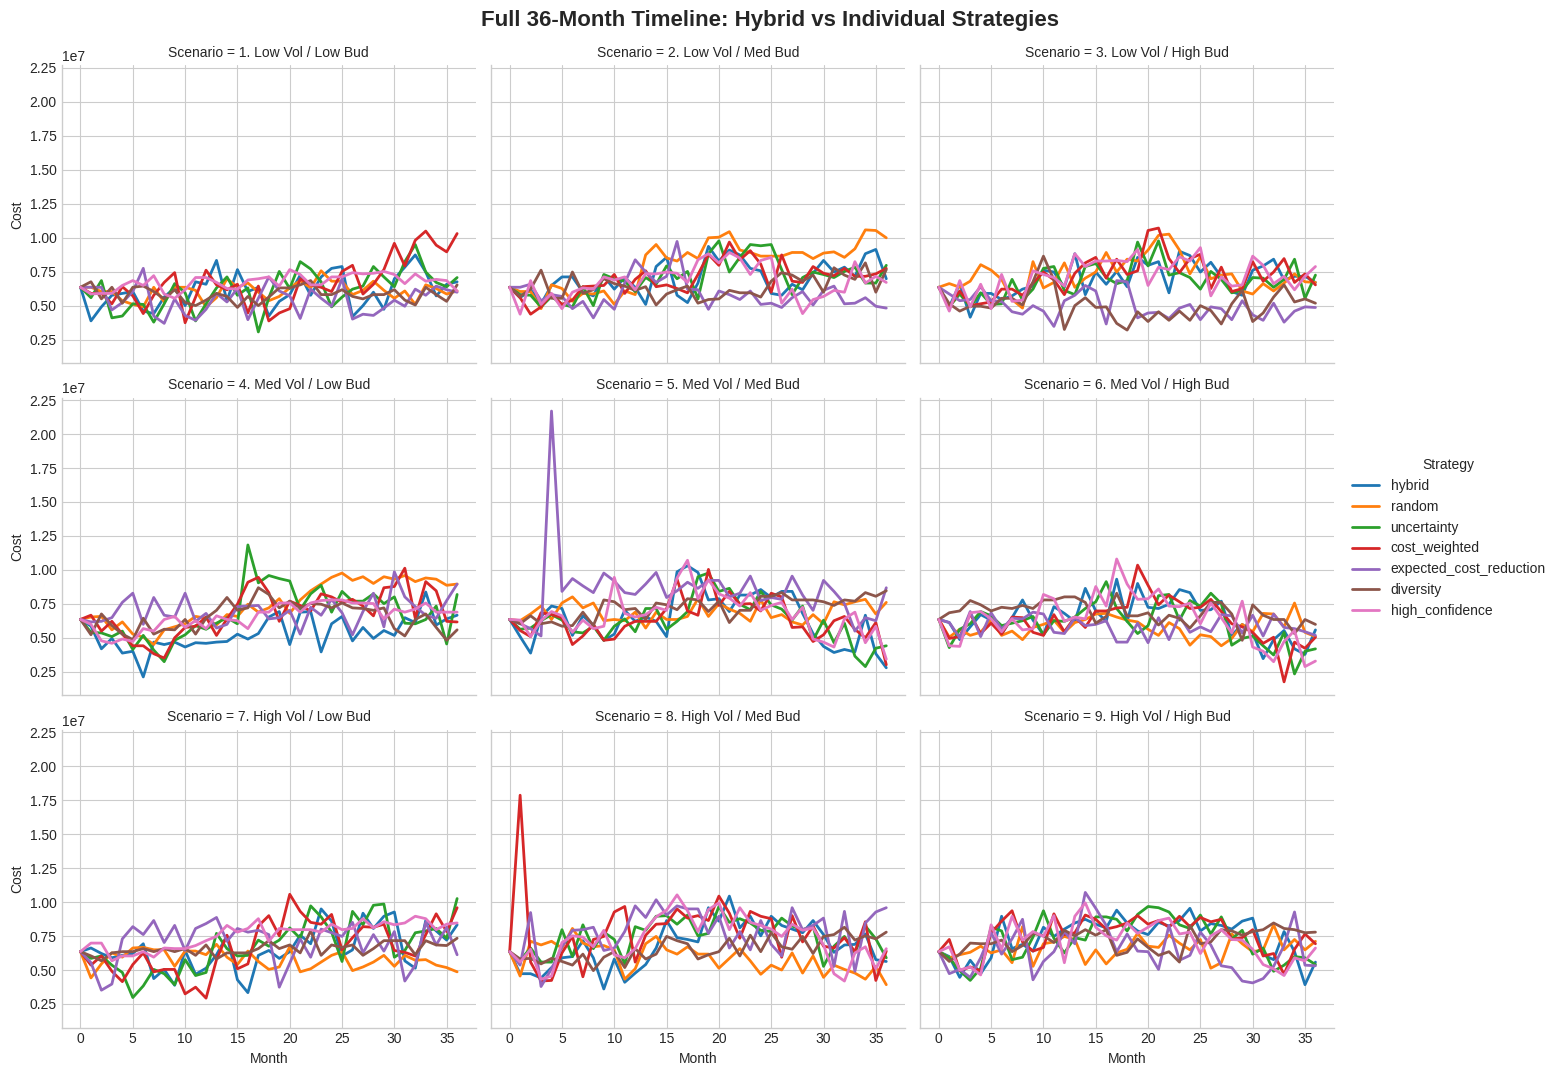

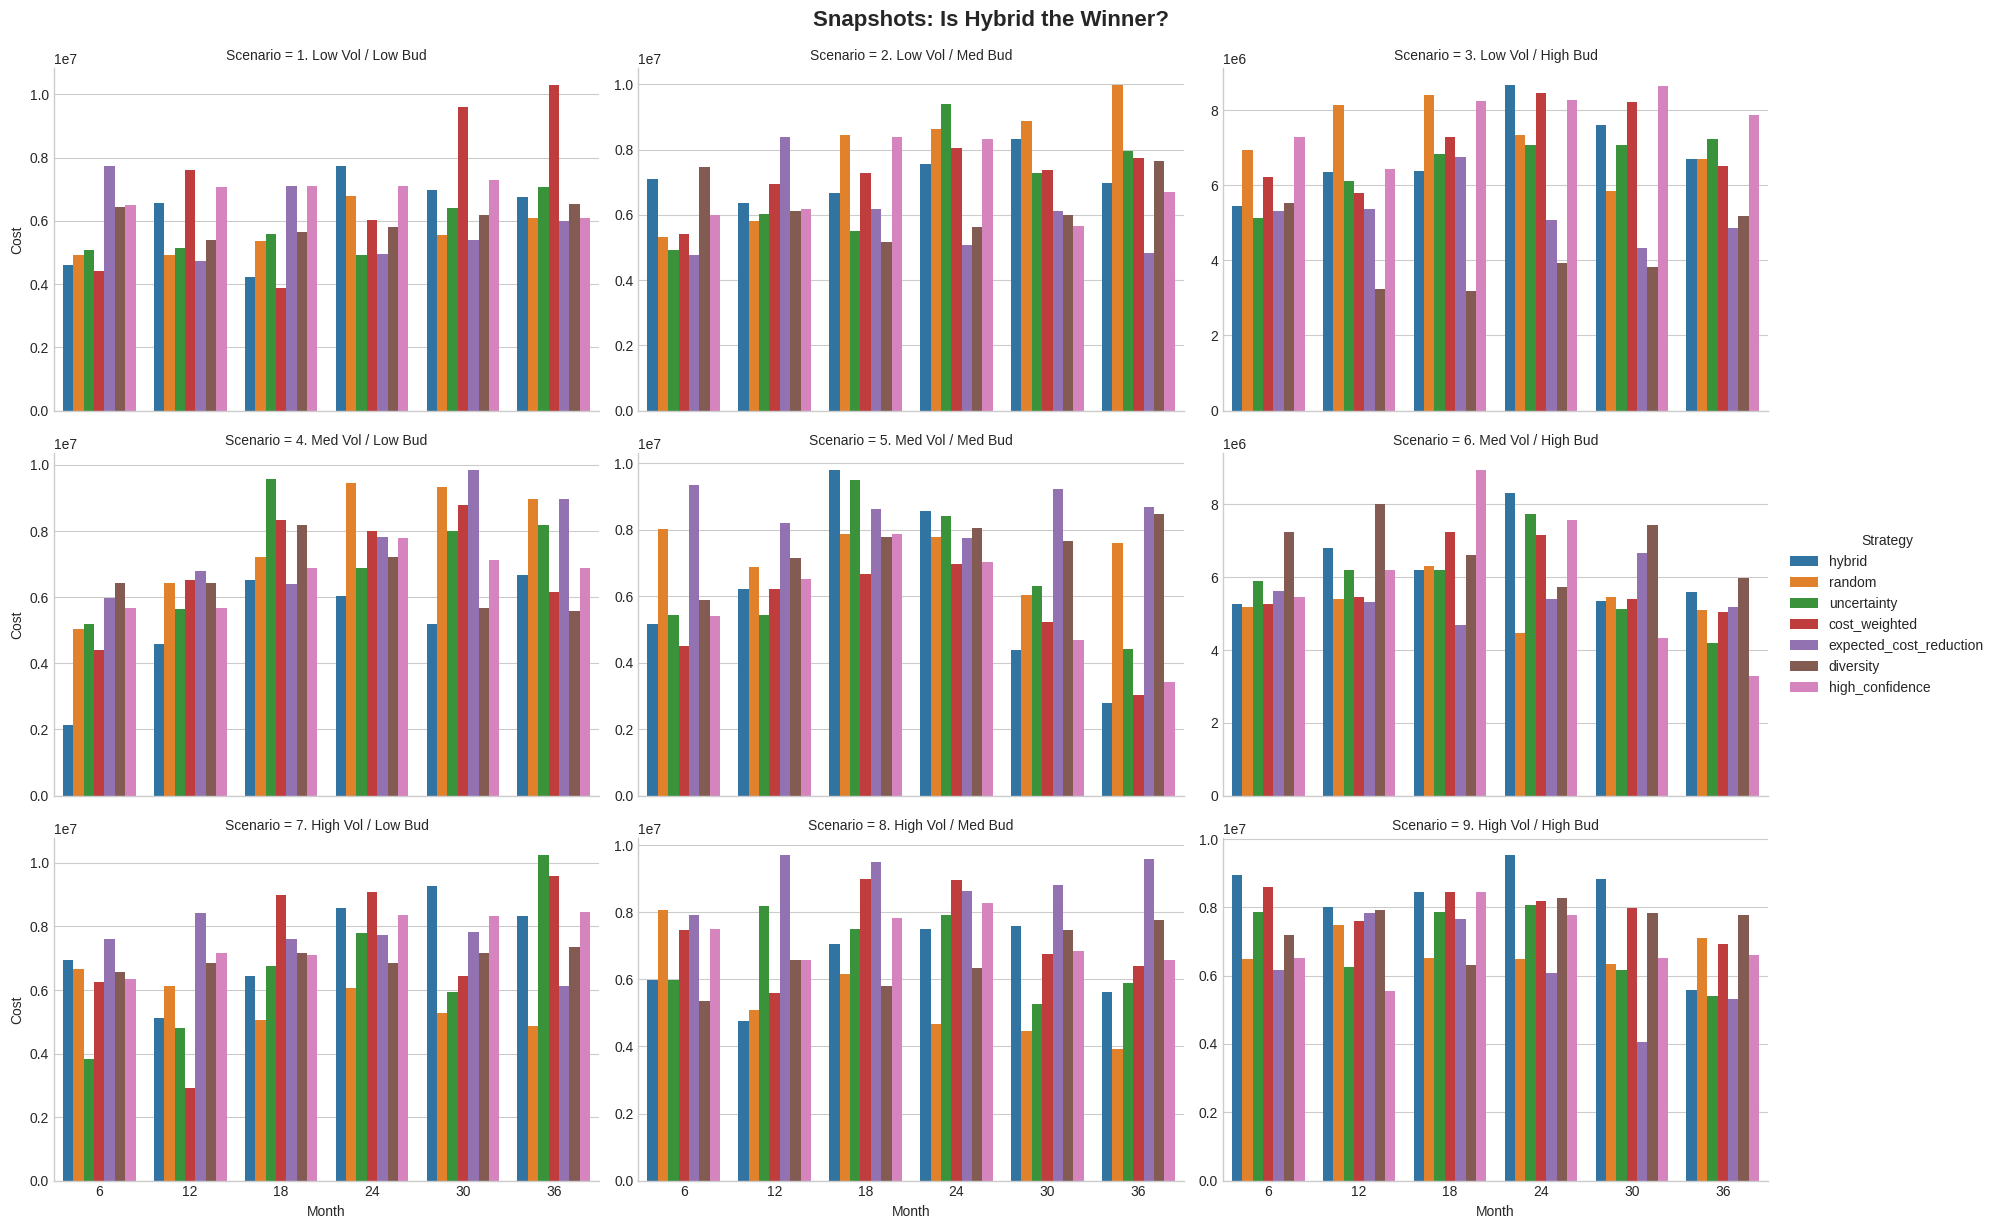


FINAL COST SUMMARY (Month 36)
Scenario                 1. Low Vol / Low Bud  2. Low Vol / Med Bud  \
Strategy                                                              
cost_weighted                      10,306,000             7,741,200   
diversity                           6,528,900             7,652,200   
expected_cost_reduction             5,987,100             4,817,700   
high_confidence                     6,076,800             6,706,200   
hybrid                              6,752,000             6,976,300   
random                              6,079,000             9,991,300   
uncertainty                         7,066,000             7,966,100   

Scenario                 3. Low Vol / High Bud  4. Med Vol / Low Bud  \
Strategy                                                               
cost_weighted                        6,526,400             6,166,800   
diversity                            5,177,300             5,586,000   
expected_cost_reduction              4,86

In [ ]:
# =============================================================================
# 1. SETUP & DATA LOADING
# =============================================================================
import zipfile
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier
from sklearn.cluster import MiniBatchKMeans
from sklearn.metrics import pairwise_distances_argmin_min
import warnings

warnings.filterwarnings('ignore')

# ---- PATHS ----
# Ensure this matches your specific environment path or upload location
ZIP_PATH = "/content/data_5L_new.zip"
EXTRACT_DIR = "/content/extracted_zip"

# ---- UNZIP & LOAD ----
if not os.path.exists(EXTRACT_DIR):
    if os.path.exists(ZIP_PATH):
        with zipfile.ZipFile(ZIP_PATH, 'r') as z:
            z.extractall(EXTRACT_DIR)
    else:
        print(f"Warning: {ZIP_PATH} not found. Ensure data is uploaded.")

csv_file = None
if os.path.exists(EXTRACT_DIR):
    for file in os.listdir(EXTRACT_DIR):
        if file.endswith(".csv"):
            csv_file = os.path.join(EXTRACT_DIR, file)
            break

if csv_file is None:
    print("No CSV file found. Please upload data_5L_new.zip to Colab.")
else:
    print("Loading dataset...")
    df = pd.read_csv(csv_file)
    print(f"Data loaded: {df.shape}")

# =============================================================================
# 2. FRAUD RULES & HELPER FUNCTIONS
# =============================================================================

def apply_fraud_rules(df):
    """Industry-standard fraud detection rules (Heuristic Labeling)."""
    flags = pd.Series(False, index=df.index)
    # Avoid division by zero
    claim_ratio = df['sum_insured'] / (df['premium_with_tax'] + 1)
    coverage_ratio = df['sum_insured'] / (df['property_market_value'] + 1)

    flags |= (claim_ratio > 1500) & (df['previous_insurance_buildings'] == 0) & (df['no_of_claims_5yr'] > 0)
    flags |= (df['accidental_damage_premium'] > 0) & (df['unoccupied_days'] >= 30) & (df['no_of_claims_5yr'] > 0)
    flags |= (df['no_of_claims_5yr'] >= 3)
    flags |= (df['unoccupied_days'] >= 30) & (df['business_use'] == 'Y') & (df['no_of_claims_5yr'] > 0)
    flags |= (coverage_ratio > 0.8) & (df['no_of_claims_5yr'] > 0)
    flags |= (df['additional_coverage_amount'] >= 15000) & (df['no_of_claims_5yr'] > 0)
    flags |= (df['premium_payment_behaviour'] < 70) & (df['no_of_claims_5yr'] >= 2)
    flags |= (df['short_term_letting'] == 1) & (df['no_of_claims_5yr'] >= 2)
    return flags

def prepare_features(df, categorical_cols=None):
    if categorical_cols is None:
        categorical_cols = ['cust_occupation', 'owner_details', 'property_type',
                           'construction_material', 'roof_material', 'urban_rural', 'policy_product', 'business_use']

    # Handle missing cols for robustness
    existing_cats = [c for c in categorical_cols if c in df.columns]

    df_encoded = pd.get_dummies(df, columns=existing_cats, drop_first=True)
    exclude_cols = ['fraud_label', 'fraud_probability', 'policy_no', 'unoccupied_reason']
    feature_cols = [col for col in df_encoded.columns if col not in exclude_cols]
    return df_encoded[feature_cols]

def calculate_costs(sum_insured, y_true, y_pred):
    costs = np.zeros(len(y_true))
    fn_mask = (y_true == 1) & (y_pred == 0)
    fp_mask = (y_true == 0) & (y_pred == 1)
    costs[fn_mask] = sum_insured[fn_mask] * 0.90 # FN Cost: Payout (Claim Amount)
    costs[fp_mask] = 100 # FP Cost: Investigation fee
    return costs

def evaluate_cost_sensitive(y_true, y_pred, sum_insured):
    costs = calculate_costs(sum_insured, y_true, y_pred)
    tp = np.sum((y_true == 1) & (y_pred == 1))
    fn_count = np.sum((y_true == 1) & (y_pred == 0))
    # Avoid division by zero
    recall = tp / (tp + fn_count) if (tp + fn_count) > 0 else 0
    return {'total_cost': np.sum(costs), 'recall': recall}

def find_optimal_threshold(model, X, y, sum_insured):
    proba = model.predict_proba(X)[:, 1]
    thresholds = np.linspace(0.1, 0.9, 50)
    best_cost = float('inf')
    best_thresh = 0.5

    for thresh in thresholds:
        y_pred = (proba >= thresh).astype(int)
        cost = np.sum(calculate_costs(sum_insured, y, y_pred))
        if cost < best_cost:
            best_cost = cost
            best_thresh = thresh
    return best_thresh

# =============================================================================
# 3. ADVANCED ACTIVE LEARNING AGENT (WITH HYBRID LOGIC)
# =============================================================================

class ActiveLearningAgent:
    def __init__(self):
        self.model = XGBClassifier(
            n_estimators=100, max_depth=6, learning_rate=0.1,
            scale_pos_weight=5, random_state=42, eval_metric='logloss', n_jobs=-1
        )
        self.scaler = StandardScaler()
        self.threshold = 0.5
        self.labeled_data = {'X': None, 'y': None, 'sum_insured': None}
        self.feature_names = None

    def _align(self, df_input):
        X_feat = prepare_features(df_input.copy())
        # Ensure all columns match training data
        for col in self.feature_names:
            if col not in X_feat.columns: X_feat[col] = 0
        return X_feat[self.feature_names].values

    def initial_train(self, df_universe, flagged_indices):
        investigated = df_universe.loc[flagged_indices]
        X_df = prepare_features(investigated.copy())
        self.feature_names = X_df.columns.tolist()

        X = X_df.values
        y = investigated['fraud_label'].values
        s = investigated['sum_insured'].values

        X_scaled = self.scaler.fit_transform(X)
        self.labeled_data = {'X': X_scaled, 'y': y, 'sum_insured': s}

        self.model.fit(X_scaled, y)
        self.threshold = find_optimal_threshold(self.model, X_scaled, y, s)

    def query(self, df_pool, budget, strategy):
        X_pool = self._align(df_pool)
        X_scaled = self.scaler.transform(X_pool)
        y_proba = self.model.predict_proba(X_scaled)[:, 1]
        sum_insured = df_pool['sum_insured'].values
        indices = df_pool.index.tolist()

        selected_idx = []

        # Helper to get remaining pool after partial selection
        def get_remaining(current_selected):
            mask = ~np.isin(indices, current_selected)
            return np.array(indices)[mask], X_scaled[mask], y_proba[mask], sum_insured[mask]

        # --- 0. HYBRID STRATEGY (The new implementation) ---
        if strategy == 'hybrid':
            # 70% Expected Cost Reduction
            n_ecr = int(budget * 0.7)
            # 20% Uncertainty
            n_unc = int(budget * 0.2)
            # 10% Random (Remainder ensures exact budget match)
            n_rnd = budget - n_ecr - n_unc

            # 1. Step: Expected Cost Reduction (70%)
            risk_if_0 = y_proba * (sum_insured * 0.90)
            risk_if_1 = (1 - y_proba) * 100
            current_risk = np.where(y_proba < self.threshold, risk_if_0, risk_if_1)

            # Sort all by risk, pick top n_ecr
            sorted_risk_indices = np.argsort(current_risk)[::-1]
            idx_ecr = [indices[i] for i in sorted_risk_indices[:n_ecr]]
            selected_idx.extend(idx_ecr)

            # 2. Step: Uncertainty (20%) from REMAINING
            rem_idx, _, rem_proba, _ = get_remaining(selected_idx)

            if len(rem_idx) > 0 and n_unc > 0:
                unc_scores = np.abs(rem_proba - 0.5) # Lower is more uncertain
                # Sort by uncertainty (ascending)
                sorted_unc_pos = np.argsort(unc_scores)
                # Map back to original indices
                idx_unc = rem_idx[sorted_unc_pos[:n_unc]].tolist()
                selected_idx.extend(idx_unc)

            # 3. Step: Random (10%) from REMAINING
            rem_idx, _, _, _ = get_remaining(selected_idx)

            if len(rem_idx) > 0 and n_rnd > 0:
                # Random sample
                safe_n = min(len(rem_idx), n_rnd)
                idx_rnd = np.random.choice(rem_idx, size=safe_n, replace=False).tolist()
                selected_idx.extend(idx_rnd)

        # --- 1. Uncertainty Sampling (Least Confidence) ---
        elif strategy == 'uncertainty':
            scores = np.abs(y_proba - 0.5)
            selected_idx = [indices[i] for i in np.argsort(scores)[:budget]]

        # --- 2. Cost-Weighted Uncertainty ---
        elif strategy == 'cost_weighted':
            uncertainty = 0.5 - np.abs(y_proba - 0.5)
            norm_cost = sum_insured / (np.max(sum_insured) + 1)
            scores = uncertainty * norm_cost
            selected_idx = [indices[i] for i in np.argsort(scores)[::-1][:budget]]

        # --- 3. Expected Cost Reduction ---
        elif strategy == 'expected_cost_reduction':
            risk_if_0 = y_proba * (sum_insured * 0.90)
            risk_if_1 = (1 - y_proba) * 100
            current_risk = np.where(y_proba < self.threshold, risk_if_0, risk_if_1)
            selected_idx = [indices[i] for i in np.argsort(current_risk)[::-1][:budget]]

        # --- 4. Diversity (Clustering) ---
        elif strategy == 'diversity':
            kmeans = MiniBatchKMeans(n_clusters=budget, random_state=42, batch_size=256, n_init='auto')
            kmeans.fit(X_scaled)
            closest, _ = pairwise_distances_argmin_min(kmeans.cluster_centers_, X_scaled)
            selected_idx = [indices[i] for i in closest]

        # --- 5. Random Sampling (Baseline) ---
        elif strategy == 'random':
            if len(indices) >= budget:
                selected_idx = np.random.choice(indices, size=budget, replace=False).tolist()
            else:
                selected_idx = indices

        # --- 6. High Confidence (Exploitation) ---
        elif strategy == 'high_confidence':
            selected_idx = [indices[i] for i in np.argsort(y_proba)[::-1][:budget]]

        return selected_idx

    def retrain(self, df_universe, new_indices):
        new_data = df_universe.loc[new_indices]
        X_new = self.scaler.transform(self._align(new_data))
        y_new = new_data['fraud_label'].values
        s_new = new_data['sum_insured'].values

        self.labeled_data['X'] = np.vstack([self.labeled_data['X'], X_new])
        self.labeled_data['y'] = np.concatenate([self.labeled_data['y'], y_new])
        self.labeled_data['sum_insured'] = np.concatenate([self.labeled_data['sum_insured'], s_new])

        self.model.fit(self.labeled_data['X'], self.labeled_data['y'])
        self.threshold = find_optimal_threshold(
            self.model, self.labeled_data['X'], self.labeled_data['y'], self.labeled_data['sum_insured']
        )

    def evaluate(self, df_test):
        X_test = self.scaler.transform(self._align(df_test))
        y_test = df_test['fraud_label'].values
        s_test = df_test['sum_insured'].values
        y_pred = (self.model.predict_proba(X_test)[:, 1] >= self.threshold).astype(int)
        return evaluate_cost_sensitive(y_test, y_pred, s_test)

# =============================================================================
# 4. SCENARIO SIMULATION LOOP (36 MONTHS)
# =============================================================================

def run_multi_scenario_comparison(df, strategies, scenarios, n_months=36):
    """
    Runs the AL loop for multiple strategies across multiple scenarios.
    """
    # 1. Common Initialization
    initial_pool = df.sample(n=10000, random_state=42)
    flags = apply_fraud_rules(initial_pool)
    flagged_idx = initial_pool[flags].index

    # Common Test Set
    avail_after_init = df.drop(index=initial_pool.index)
    test_set = avail_after_init.sample(n=5000, random_state=999)
    base_used_indices = set(initial_pool.index) | set(test_set.index)

    all_results = []

    print(f"{'='*80}")
    print(f"STARTING 36-MONTH HYBRID SIMULATION ({len(scenarios)} Scenarios)")
    print(f"Strategies: {strategies}")
    print(f"{'='*80}")

    for scenario in scenarios:
        scen_name = scenario['name']
        monthly_vol = scenario['vol']
        budget = scenario['budget']

        print(f"\n>> Processing: {scen_name}")

        for strat in strategies:
            # Reset Agent
            agent = ActiveLearningAgent()
            agent.initial_train(df, flagged_idx)

            # Local copy of used indices for this run
            current_used_indices = base_used_indices.copy()

            # Baseline (Month 0)
            base_metrics = agent.evaluate(test_set)
            all_results.append({
                'Scenario': scen_name,
                'Strategy': strat,
                'Month': 0,
                'Cost': base_metrics['total_cost'],
                'Recall': base_metrics['recall']
            })

            # Simulation Loop
            for month in range(1, n_months + 1):
                # Ensure every strategy/scenario gets the SAME batch for specific month
                available = df.drop(index=current_used_indices)

                if len(available) < monthly_vol:
                    break

                # Seed = month + 100 ensures consistency
                new_batch = available.sample(n=monthly_vol, random_state=(month + 100))
                current_used_indices.update(new_batch.index)

                # Query (Includes Hybrid Logic now)
                query_idx = agent.query(new_batch, budget, strat)

                # Retrain
                agent.retrain(df, query_idx)

                # Evaluate
                metrics = agent.evaluate(test_set)
                all_results.append({
                    'Scenario': scen_name,
                    'Strategy': strat,
                    'Month': month,
                    'Cost': metrics['total_cost'],
                    'Recall': metrics['recall']
                })

                if month % 6 == 0:
                    print(f"   [{strat}] Month {month} complete.", end='\r')

    return pd.DataFrame(all_results)

# =============================================================================
# 5. EXECUTION & VISUALIZATION
# =============================================================================

# ---- CONFIGURATION ----
# Added 'hybrid' to the comparison
STRATEGIES_TO_TEST = [
    'hybrid',                  # <--- NEW HYBRID STRATEGY
    'random',
    'uncertainty',
    'cost_weighted',
    'expected_cost_reduction',
    'diversity',
    'high_confidence'
]

# Define 9 Scenarios
SCENARIOS = [
    # --- LOW VOLUME (1000) ---
    {'name': '1. Low Vol / Low Bud',   'vol': 1000, 'budget': 50},
    {'name': '2. Low Vol / Med Bud',   'vol': 1000, 'budget': 150},
    {'name': '3. Low Vol / High Bud',  'vol': 1000, 'budget': 300},

    # --- MED VOLUME (1500) ---
    {'name': '4. Med Vol / Low Bud',   'vol': 1500, 'budget': 50},
    {'name': '5. Med Vol / Med Bud',   'vol': 1500, 'budget': 150},
    {'name': '6. Med Vol / High Bud',  'vol': 1500, 'budget': 300},

    # --- HIGH VOLUME (2000) ---
    {'name': '7. High Vol / Low Bud',  'vol': 2000, 'budget': 50},
    {'name': '8. High Vol / Med Bud',  'vol': 2000, 'budget': 150},
    {'name': '9. High Vol / High Bud', 'vol': 2000, 'budget': 300},
]

# Run Simulation
if 'df' in locals():
    df_results = run_multi_scenario_comparison(
        df,
        strategies=STRATEGIES_TO_TEST,
        scenarios=SCENARIOS,
        n_months=36
    )

    # ---- PLOTTING ----
    plt.style.use('seaborn-v0_8-whitegrid')

    # VIEW 1: Full Timeline 0-36 Months (Cost)
    g_cost = sns.relplot(
        data=df_results,
        x="Month", y="Cost",
        hue="Strategy",
        col="Scenario",
        col_wrap=3,
        kind="line",
        marker="", linewidth=2,
        palette='tab10',
        height=3.5, aspect=1.3
    )
    g_cost.fig.suptitle('Full 36-Month Timeline: Hybrid vs Individual Strategies', y=1.02, fontsize=16, fontweight='bold')
    plt.show()

    # VIEW 2: Comparison Snapshots
    snapshots = [6, 12, 18, 24, 30, 36]
    df_snap = df_results[df_results['Month'].isin(snapshots)]

    g_snap = sns.catplot(
        data=df_snap,
        x="Month", y="Cost",
        hue="Strategy",
        col="Scenario",
        col_wrap=3,
        kind="bar",
        palette='tab10',
        height=4, aspect=1.5,
        sharey=False
    )
    g_snap.fig.suptitle('Snapshots: Is Hybrid the Winner?', y=1.02, fontsize=16, fontweight='bold')
    plt.show()

    # VIEW 3: Final Summary Table (Month 36)
    final_data = df_results[df_results['Month'] == 36]

    print("\n" + "="*50)
    print("FINAL COST SUMMARY (Month 36)")
    print("="*50)
    pivot_cost = final_data.pivot(index='Strategy', columns='Scenario', values='Cost')
    pd.options.display.float_format = '{:,.0f}'.format
    print(pivot_cost)

    print("\n" + "="*50)
    print("FINAL RECALL SUMMARY (Month 36)")
    print("="*50)
    pivot_recall = final_data.pivot(index='Strategy', columns='Scenario', values='Recall')
    pd.options.display.float_format = '{:,.2%}'.format
    print(pivot_recall)

else:
    print("Skipping execution: Dataset not loaded.")

# Detail fraud rule breakdown and Updated Diversity strategy

Loading dataset...
Data loaded: (500000, 50)

==================== FRAUD RULE BREAKDOWN ====================
1. High Claim Ratio & No Prev Ins            :   297 flagged
2. Accidental Dmg & Unoccupied               :   170 flagged
3. Frequent Claims (3+)                      :   516 flagged
4. Business Use & Unoccupied                 :    20 flagged
------------------------------------------------------------
Total Unique Flagged Transactions            :   907 flagged

STARTING COMPARISON OF 4 STRATEGIES

>> Running Strategy: UNCERTAINTY

>> Running Strategy: COST_WEIGHTED

>> Running Strategy: EXPECTED_COST_REDUCTION

>> Running Strategy: DIVERSITY


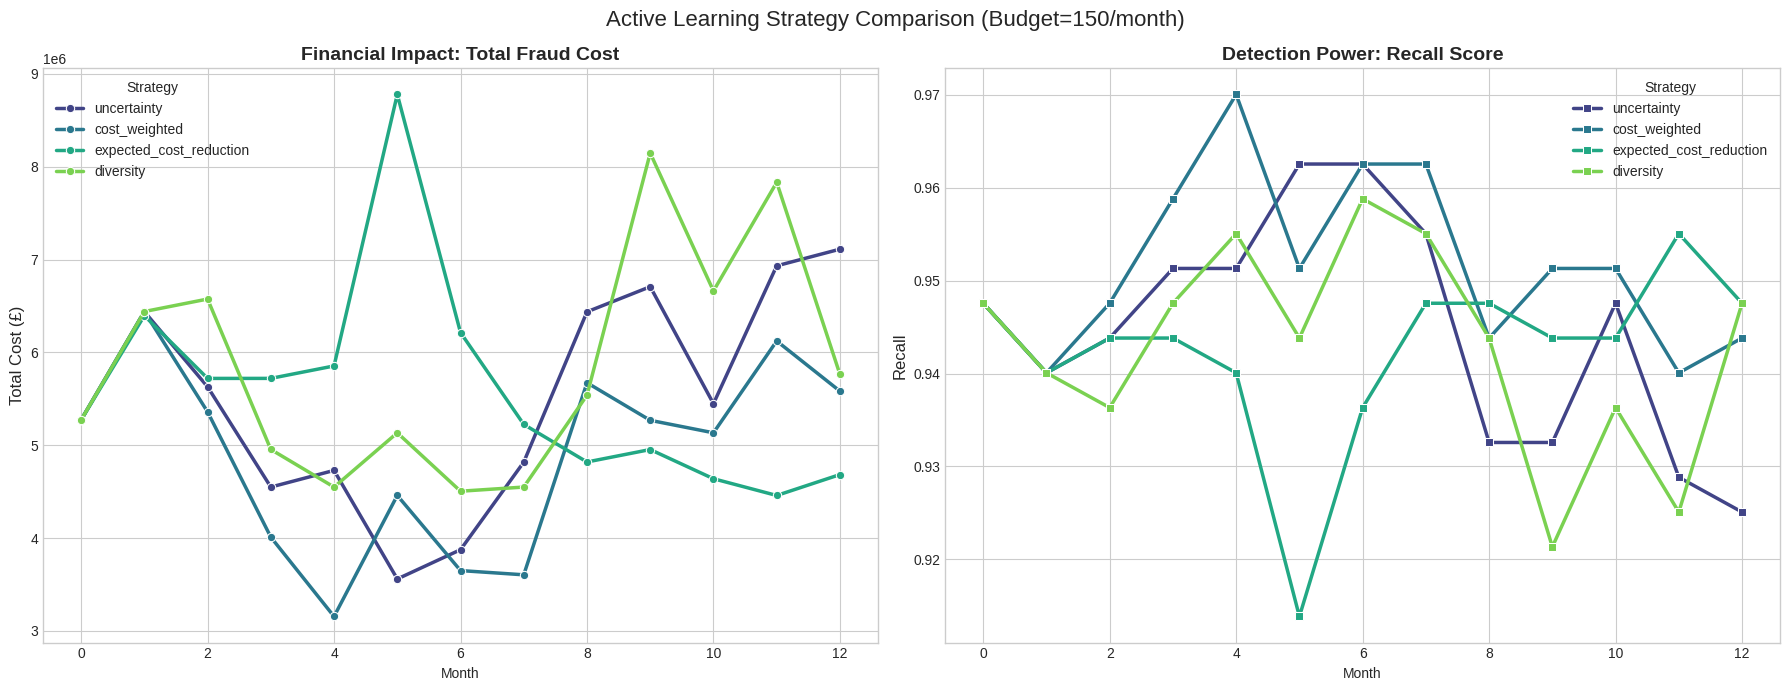


Final Cost Comparison (Month 6):
  cost_weighted            : £3,649,100 (Saved: £1,622,800)
  uncertainty              : £3,873,900 (Saved: £1,398,000)
  diversity                : £4,504,100 (Saved: £767,800)
  expected_cost_reduction  : £6,213,500 (Saved: £-941,600)


In [ ]:
# =============================================================================
# 1. SETUP & DATA LOADING
# =============================================================================
import zipfile
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier
from sklearn.cluster import MiniBatchKMeans
from sklearn.metrics import pairwise_distances_argmin_min
import warnings

warnings.filterwarnings('ignore')  # Clean output

# ---- PATHS ----
ZIP_PATH = "/content/data_5L_new.zip"
EXTRACT_DIR = "/content/extracted_zip"

# ---- UNZIP & LOAD ----
if not os.path.exists(EXTRACT_DIR):
    with zipfile.ZipFile(ZIP_PATH, 'r') as z:
        z.extractall(EXTRACT_DIR)

csv_file = None
for file in os.listdir(EXTRACT_DIR):
    if file.endswith(".csv"):
        csv_file = os.path.join(EXTRACT_DIR, file)
        break

if csv_file is None:
    raise FileNotFoundError("No CSV file found inside the ZIP.")

print("Loading dataset...")
df = pd.read_csv(csv_file)
print(f"Data loaded: {df.shape}")

# =============================================================================
# 2. FRAUD RULES & ANALYSIS
# =============================================================================

def analyze_fraud_rules(df):
    """
    Applies rules individually to track counts, then returns the combined flag.
    """
    print(f"\n{'='*20} FRAUD RULE BREAKDOWN {'='*20}")

    # Pre-calculations
    claim_ratio = df['sum_insured'] / (df['premium_with_tax'] + 1)
    coverage_ratio = df['sum_insured'] / (df['property_market_value'] + 1)

    # Define Rules Dictionary
    rules = {
        "1. High Claim Ratio & No Prev Ins": (claim_ratio > 1500) & (df['previous_insurance_buildings'] == 0) & (df['no_of_claims_5yr'] > 0),
        "2. Accidental Dmg & Unoccupied": (df['accidental_damage_premium'] > 0) & (df['unoccupied_days'] >= 30) & (df['no_of_claims_5yr'] > 0),
        "3. Frequent Claims (3+)": (df['no_of_claims_5yr'] >= 3),
        "4. Business Use & Unoccupied": (df['unoccupied_days'] >= 30) & (df['business_use'] == 'Y') & (df['no_of_claims_5yr'] > 0),
        # "5. Over-insured (>80% Market Val)": (coverage_ratio > 0.8) & (df['no_of_claims_5yr'] > 0),
        # "6. High Add. Coverage (>15k)": (df['additional_coverage_amount'] >= 15000) & (df['no_of_claims_5yr'] > 0),
        # "7. Poor Payment Behavior": (df['premium_payment_behaviour'] < 70) & (df['no_of_claims_5yr'] >= 2),
        # "8. Short Term Letting": (df['short_term_letting'] == 1) & (df['no_of_claims_5yr'] >= 2)
    }

    combined_flags = pd.Series(False, index=df.index)

    # Print counts for each rule
    for name, mask in rules.items():
        count = mask.sum()
        print(f"{name.ljust(45)}: {count:5d} flagged")
        combined_flags |= mask

    print(f"{'-'*60}")
    print(f"{'Total Unique Flagged Transactions'.ljust(45)}: {combined_flags.sum():5d} flagged")
    print(f"{'='*60}\n")

    return combined_flags

def prepare_features(df, categorical_cols=None):
    if categorical_cols is None:
        categorical_cols = ['cust_occupation', 'owner_details', 'property_type',
                            'construction_material', 'roof_material', 'urban_rural', 'policy_product', 'business_use']
    df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)
    exclude_cols = ['fraud_label', 'fraud_probability', 'policy_no', 'unoccupied_reason']
    feature_cols = [col for col in df_encoded.columns if col not in exclude_cols]
    return df_encoded[feature_cols]

def calculate_costs(sum_insured, y_true, y_pred):
    costs = np.zeros(len(y_true))
    fn_mask = (y_true == 1) & (y_pred == 0)
    fp_mask = (y_true == 0) & (y_pred == 1)
    costs[fn_mask] = sum_insured[fn_mask] * 0.90  # FN Cost: Payout
    costs[fp_mask] = 100  # FP Cost: Investigation fee
    return costs

def evaluate_cost_sensitive(y_true, y_pred, sum_insured):
    costs = calculate_costs(sum_insured, y_true, y_pred)
    tp = np.sum((y_true == 1) & (y_pred == 1))
    fn_count = np.sum((y_true == 1) & (y_pred == 0))
    recall = tp / (tp + fn_count) if (tp + fn_count) > 0 else 0
    return {'total_cost': np.sum(costs), 'recall': recall}

def find_optimal_threshold(model, X, y, sum_insured):
    proba = model.predict_proba(X)[:, 1]
    thresholds = np.linspace(0.1, 0.9, 50)
    best_cost = float('inf')
    best_thresh = 0.5
    for thresh in thresholds:
        y_pred = (proba >= thresh).astype(int)
        cost = np.sum(calculate_costs(sum_insured, y, y_pred))
        if cost < best_cost:
            best_cost = cost
            best_thresh = thresh
    return best_thresh

# =============================================================================
# 3. ADVANCED ACTIVE LEARNING CLASS
# =============================================================================

class ActiveLearningAgent:
    def __init__(self):
        self.model = XGBClassifier(
            n_estimators=100, max_depth=6, learning_rate=0.1,
            scale_pos_weight=5, random_state=42, eval_metric='logloss', n_jobs=-1
        )
        self.scaler = StandardScaler()
        self.threshold = 0.5
        self.labeled_data = {'X': None, 'y': None, 'sum_insured': None}
        self.feature_names = None

    def _align(self, df_input):
        X_feat = prepare_features(df_input.copy())
        for col in self.feature_names:
            if col not in X_feat.columns: X_feat[col] = 0
        return X_feat[self.feature_names].values

    def initial_train(self, df_universe, flagged_indices):
        investigated = df_universe.loc[flagged_indices]
        X_df = prepare_features(investigated.copy())
        self.feature_names = X_df.columns.tolist()

        X = X_df.values
        y = investigated['fraud_label'].values
        s = investigated['sum_insured'].values

        X_scaled = self.scaler.fit_transform(X)
        self.labeled_data = {'X': X_scaled, 'y': y, 'sum_insured': s}

        self.model.fit(X_scaled, y)
        self.threshold = find_optimal_threshold(self.model, X_scaled, y, s)

    def query(self, df_pool, budget, strategy):
        X_pool = self._align(df_pool)
        X_scaled = self.scaler.transform(X_pool)
        y_proba = self.model.predict_proba(X_scaled)[:, 1]
        sum_insured = df_pool['sum_insured'].values
        indices = df_pool.index.tolist()

        if strategy == 'uncertainty':
            scores = np.abs(y_proba - 0.5)
            selected_idx = [indices[i] for i in np.argsort(scores)[:budget]]

        elif strategy == 'cost_weighted':
            uncertainty = 0.5 - np.abs(y_proba - 0.5)
            norm_cost = sum_insured / (np.max(sum_insured) + 1)
            scores = uncertainty * norm_cost
            selected_idx = [indices[i] for i in np.argsort(scores)[::-1][:budget]]

        elif strategy == 'expected_cost_reduction':
            risk_if_0 = y_proba * (sum_insured * 0.90)
            risk_if_1 = (1 - y_proba) * 100
            current_risk = np.where(y_proba < self.threshold, risk_if_0, risk_if_1)
            selected_idx = [indices[i] for i in np.argsort(current_risk)[::-1][:budget]]

        elif strategy == 'diversity':
            # --- UPDATED DIVERSITY STRATEGY ---

            # 1. Clustering based on FEATURES (to find groups)
            # Use more clusters than budget to ensure granular groups
            n_clusters = max(5, budget // 2)
            kmeans = MiniBatchKMeans(n_clusters=n_clusters, random_state=42, batch_size=256)
            cluster_labels = kmeans.fit_predict(X_scaled)

            # 2. Calculate Distance to Centroids (Boundary detection)
            # transform() returns distance to all centers; we take min (dist to own center)
            dists = kmeans.transform(X_scaled)
            dist_to_center = np.min(dists, axis=1)

            # 3. Organize Data
            pool_data = pd.DataFrame({
                'idx': indices,
                'cluster': cluster_labels,
                'prob': y_proba,
                'dist': dist_to_center
            })

            # 4. Filter Noise: Remove clusters with fewer than MIN_POINTS
            MIN_POINTS = 5
            cluster_counts = pool_data['cluster'].value_counts()
            valid_clusters = cluster_counts[cluster_counts >= MIN_POINTS].index
            pool_data = pool_data[pool_data['cluster'].isin(valid_clusters)]

            # 5. Calculate Selection Score
            # Score = Uncertainty (Primary) + Boundary Distance (Secondary)
            # Uncertainty: Closer to 0.5 is better. (1 - |2*prob - 1|) gives 1 at prob=0.5
            uncertainty_score = 1 - np.abs(2 * pool_data['prob'] - 1)

            # Normalize distance for combination
            dist_score = (pool_data['dist'] - pool_data['dist'].min()) / (pool_data['dist'].max() - pool_data['dist'].min() + 1e-6)

            # Weighted Score: We prefer Uncertain points, but if equal, prefer Boundary points
            pool_data['score'] = uncertainty_score + (0.5 * dist_score)

            # 6. Round-Robin Selection
            selected_idx = []

            # Sort within clusters by score
            groups = pool_data.groupby('cluster')
            sorted_groups = {k: v.sort_values('score', ascending=False) for k, v in groups}

            # Cycle through clusters picking top candidate
            active_clusters = list(sorted_groups.keys())
            while len(selected_idx) < budget and active_clusters:
                for c_id in list(active_clusters): # Iterate copy to allow removal
                    if len(selected_idx) >= budget:
                        break

                    if not sorted_groups[c_id].empty:
                        # Pick top point
                        top_point = sorted_groups[c_id].iloc[0]
                        selected_idx.append(top_point['idx'])
                        # Remove picked point
                        sorted_groups[c_id] = sorted_groups[c_id].iloc[1:]
                    else:
                        active_clusters.remove(c_id)

        return selected_idx

    def retrain(self, df_universe, new_indices):
        new_data = df_universe.loc[new_indices]
        X_new = self.scaler.transform(self._align(new_data))
        y_new = new_data['fraud_label'].values
        s_new = new_data['sum_insured'].values

        self.labeled_data['X'] = np.vstack([self.labeled_data['X'], X_new])
        self.labeled_data['y'] = np.concatenate([self.labeled_data['y'], y_new])
        self.labeled_data['sum_insured'] = np.concatenate([self.labeled_data['sum_insured'], s_new])

        self.model.fit(self.labeled_data['X'], self.labeled_data['y'])
        self.threshold = find_optimal_threshold(
            self.model, self.labeled_data['X'], self.labeled_data['y'], self.labeled_data['sum_insured']
        )

    def evaluate(self, df_test):
        X_test = self.scaler.transform(self._align(df_test))
        y_test = df_test['fraud_label'].values
        s_test = df_test['sum_insured'].values
        y_pred = (self.model.predict_proba(X_test)[:, 1] >= self.threshold).astype(int)
        return evaluate_cost_sensitive(y_test, y_pred, s_test)

# =============================================================================
# 4. COMPARATIVE SIMULATION LOOP
# =============================================================================

def run_comparison(df, strategies, n_months=6, monthly_vol=1000, budget=200):
    # 1. Common Pre-processing & Fraud Analysis
    initial_pool = df.sample(n=10000, random_state=42)

    # --- CHANGED: Use new analyze function here ---
    flags = analyze_fraud_rules(initial_pool)
    flagged_idx = initial_pool[flags].index

    # Common Test Set
    avail_after_init = df.drop(index=initial_pool.index)
    test_set = avail_after_init.sample(n=5000, random_state=999)

    # Track used indices for the simulation stream
    base_used_indices = set(initial_pool.index) | set(test_set.index)

    all_results = []

    print(f"{'='*80}")
    print(f"STARTING COMPARISON OF {len(strategies)} STRATEGIES")
    print(f"{'='*80}")

    for strat in strategies:
        print(f"\n>> Running Strategy: {strat.upper()}")

        # Reset Agent
        agent = ActiveLearningAgent()
        agent.initial_train(df, flagged_idx)

        # Local copy of used indices for this run
        current_used_indices = base_used_indices.copy()

        # Baseline
        base_metrics = agent.evaluate(test_set)
        all_results.append({
            'Strategy': strat, 'Month': 0,
            'Cost': base_metrics['total_cost'], 'Recall': base_metrics['recall']
        })

        for month in range(1, n_months + 1):
            # Ensure every strategy gets the SAME batch of new customers
            available = df.drop(index=current_used_indices)
            if len(available) < monthly_vol: break

            new_batch = available.sample(n=monthly_vol, random_state=month)
            current_used_indices.update(new_batch.index)

            query_idx = agent.query(new_batch, budget, strat)
            agent.retrain(df, query_idx)

            metrics = agent.evaluate(test_set)
            all_results.append({
                'Strategy': strat, 'Month': month,
                'Cost': metrics['total_cost'], 'Recall': metrics['recall']
            })

    return pd.DataFrame(all_results)

# =============================================================================
# 5. EXECUTE & VISUALIZE
# =============================================================================

STRATEGIES_TO_TEST = [
    'uncertainty',
    'cost_weighted',
    'expected_cost_reduction',
    'diversity'
]

# Run Simulation
df_results = run_comparison(
    df,
    strategies=STRATEGIES_TO_TEST,
    n_months=12,
    monthly_vol=1000,
    budget=150
)

# ---- PLOTTING ----
plt.style.use('seaborn-v0_8-whitegrid')
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# 1. Total Cost
sns.lineplot(data=df_results, x='Month', y='Cost', hue='Strategy',
             marker='o', linewidth=2.5, ax=axes[0], palette='viridis')
axes[0].set_title('Financial Impact: Total Fraud Cost', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Total Cost (£)', fontsize=12)

# 2. Recall
sns.lineplot(data=df_results, x='Month', y='Recall', hue='Strategy',
             marker='s', linewidth=2.5, ax=axes[1], palette='viridis')
axes[1].set_title('Detection Power: Recall Score', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Recall', fontsize=12)

plt.suptitle(f'Active Learning Strategy Comparison (Budget={150}/month)', fontsize=16)
plt.tight_layout()
plt.show()

# ---- SUMMARY TABLE ----
pivot_cost = df_results.pivot(index='Strategy', columns='Month', values='Cost')
print("\nFinal Cost Comparison (Month 6):")
final_costs = pivot_cost[6].sort_values()
baseline_cost = pivot_cost[0].mean()
for strat, cost in final_costs.items():
    saving = baseline_cost - cost
    print(f"  {strat.ljust(25)}: £{cost:,.0f} (Saved: £{saving:,.0f})")

# Fraud rule breakdown, Updated Diversity strategy, with accuracy and F1 score

Loading dataset...
Data loaded: (500000, 50)

==================== FRAUD RULE BREAKDOWN ====================
1. High Claim Ratio & No Prev Ins            :   297 flagged
2. Accidental Dmg & Unoccupied               :   170 flagged
3. Frequent Claims (3+)                      :   516 flagged
4. Business Use & Unoccupied                 :    20 flagged
------------------------------------------------------------
Total Unique Flagged Transactions            :   907 flagged

STARTING COMPARISON OF 4 STRATEGIES

>> Running Strategy: UNCERTAINTY

>> Running Strategy: COST_WEIGHTED

>> Running Strategy: EXPECTED_COST_REDUCTION

>> Running Strategy: DIVERSITY


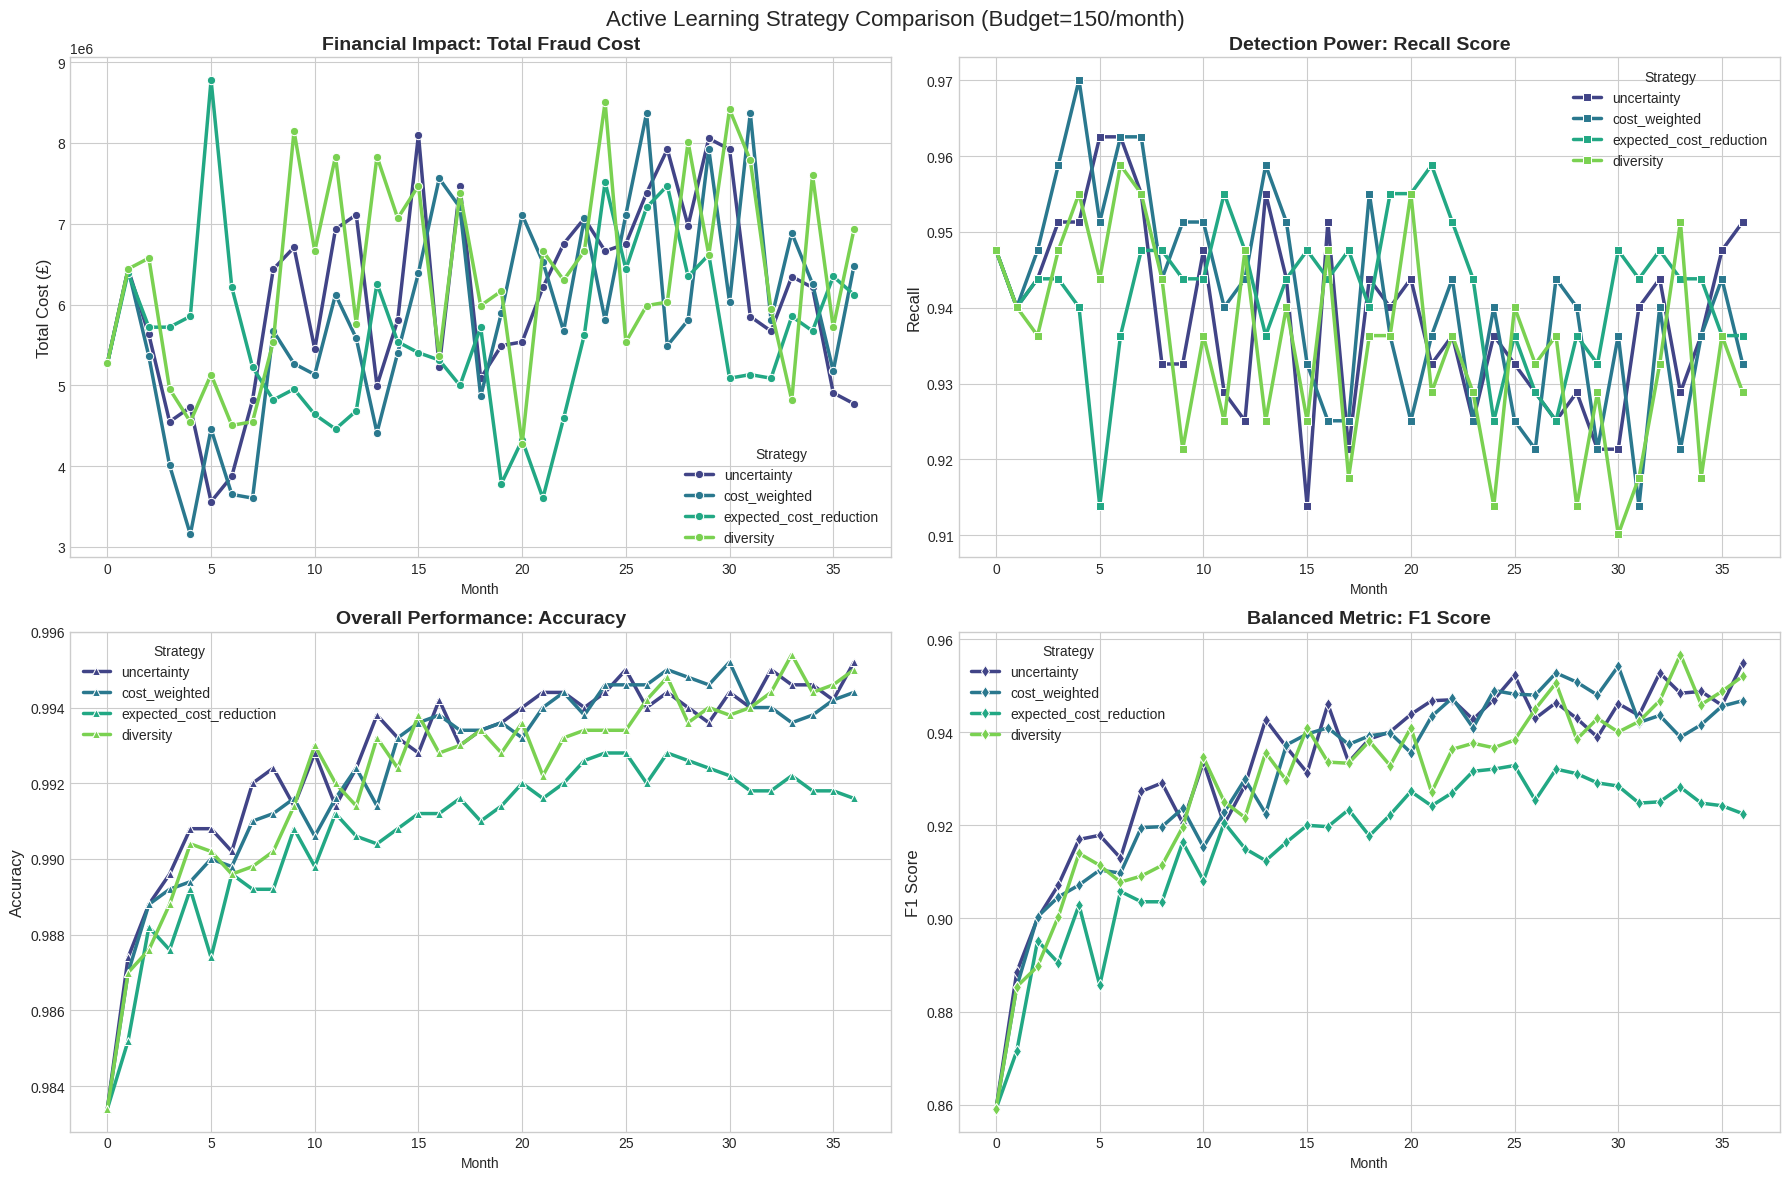


Final F1 Score Comparison (Month 12):
  cost_weighted            : 0.9299
  uncertainty              : 0.9286
  diversity                : 0.9217
  expected_cost_reduction  : 0.9150


In [ ]:
# =============================================================================
# 1. SETUP & DATA LOADING
# =============================================================================
import zipfile
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier
from sklearn.cluster import MiniBatchKMeans
from sklearn.metrics import pairwise_distances_argmin_min, accuracy_score, f1_score
import warnings

warnings.filterwarnings('ignore')  # Clean output

# ---- PATHS ----
ZIP_PATH = "/content/data_5L_new.zip"
EXTRACT_DIR = "/content/extracted_zip"

# ---- UNZIP & LOAD ----
if not os.path.exists(EXTRACT_DIR):
    with zipfile.ZipFile(ZIP_PATH, 'r') as z:
        z.extractall(EXTRACT_DIR)

csv_file = None
for file in os.listdir(EXTRACT_DIR):
    if file.endswith(".csv"):
        csv_file = os.path.join(EXTRACT_DIR, file)
        break

if csv_file is None:
    raise FileNotFoundError("No CSV file found inside the ZIP.")

print("Loading dataset...")
df = pd.read_csv(csv_file)
print(f"Data loaded: {df.shape}")

# =============================================================================
# 2. FRAUD RULES & ANALYSIS
# =============================================================================

def analyze_fraud_rules(df):
    """
    Applies rules individually to track counts, then returns the combined flag.
    """
    print(f"\n{'='*20} FRAUD RULE BREAKDOWN {'='*20}")

    # Pre-calculations
    claim_ratio = df['sum_insured'] / (df['premium_with_tax'] + 1)
    # coverage_ratio = df['sum_insured'] / (df['property_market_value'] + 1) # (Uncomment if needed)

    # Define Rules Dictionary
    rules = {
        "1. High Claim Ratio & No Prev Ins": (claim_ratio > 1500) & (df['previous_insurance_buildings'] == 0) & (df['no_of_claims_5yr'] > 0),
        "2. Accidental Dmg & Unoccupied": (df['accidental_damage_premium'] > 0) & (df['unoccupied_days'] >= 30) & (df['no_of_claims_5yr'] > 0),
        "3. Frequent Claims (3+)": (df['no_of_claims_5yr'] >= 3),
        "4. Business Use & Unoccupied": (df['unoccupied_days'] >= 30) & (df['business_use'] == 'Y') & (df['no_of_claims_5yr'] > 0),
    }

    combined_flags = pd.Series(False, index=df.index)

    # Print counts for each rule
    for name, mask in rules.items():
        count = mask.sum()
        print(f"{name.ljust(45)}: {count:5d} flagged")
        combined_flags |= mask

    print(f"{'-'*60}")
    print(f"{'Total Unique Flagged Transactions'.ljust(45)}: {combined_flags.sum():5d} flagged")
    print(f"{'='*60}\n")

    return combined_flags

def prepare_features(df, categorical_cols=None):
    if categorical_cols is None:
        categorical_cols = ['cust_occupation', 'owner_details', 'property_type',
                            'construction_material', 'roof_material', 'urban_rural', 'policy_product', 'business_use']
    df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)
    exclude_cols = ['fraud_label', 'fraud_probability', 'policy_no', 'unoccupied_reason']
    feature_cols = [col for col in df_encoded.columns if col not in exclude_cols]
    return df_encoded[feature_cols]

def calculate_costs(sum_insured, y_true, y_pred):
    costs = np.zeros(len(y_true))
    fn_mask = (y_true == 1) & (y_pred == 0)
    fp_mask = (y_true == 0) & (y_pred == 1)
    costs[fn_mask] = sum_insured[fn_mask] * 0.90  # FN Cost: Payout
    costs[fp_mask] = 100  # FP Cost: Investigation fee
    return costs

def evaluate_cost_sensitive(y_true, y_pred, sum_insured):
    # 1. Financial Metrics
    costs = calculate_costs(sum_insured, y_true, y_pred)
    tp = np.sum((y_true == 1) & (y_pred == 1))
    fn_count = np.sum((y_true == 1) & (y_pred == 0))
    recall = tp / (tp + fn_count) if (tp + fn_count) > 0 else 0

    # 2. Performance Metrics (Accuracy & F1)
    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)

    return {
        'total_cost': np.sum(costs),
        'recall': recall,
        'accuracy': acc,
        'f1': f1
    }

def find_optimal_threshold(model, X, y, sum_insured):
    proba = model.predict_proba(X)[:, 1]
    thresholds = np.linspace(0.1, 0.9, 50)
    best_cost = float('inf')
    best_thresh = 0.5
    for thresh in thresholds:
        y_pred = (proba >= thresh).astype(int)
        cost = np.sum(calculate_costs(sum_insured, y, y_pred))
        if cost < best_cost:
            best_cost = cost
            best_thresh = thresh
    return best_thresh

# =============================================================================
# 3. ADVANCED ACTIVE LEARNING CLASS
# =============================================================================

class ActiveLearningAgent:
    def __init__(self):
        self.model = XGBClassifier(
            n_estimators=100, max_depth=6, learning_rate=0.1,
            scale_pos_weight=5, random_state=42, eval_metric='logloss', n_jobs=-1
        )
        self.scaler = StandardScaler()
        self.threshold = 0.5
        self.labeled_data = {'X': None, 'y': None, 'sum_insured': None}
        self.feature_names = None

    def _align(self, df_input):
        X_feat = prepare_features(df_input.copy())
        for col in self.feature_names:
            if col not in X_feat.columns: X_feat[col] = 0
        return X_feat[self.feature_names].values

    def initial_train(self, df_universe, flagged_indices):
        investigated = df_universe.loc[flagged_indices]
        X_df = prepare_features(investigated.copy())
        self.feature_names = X_df.columns.tolist()

        X = X_df.values
        y = investigated['fraud_label'].values
        s = investigated['sum_insured'].values

        X_scaled = self.scaler.fit_transform(X)
        self.labeled_data = {'X': X_scaled, 'y': y, 'sum_insured': s}

        self.model.fit(X_scaled, y)
        self.threshold = find_optimal_threshold(self.model, X_scaled, y, s)

    def query(self, df_pool, budget, strategy):
        X_pool = self._align(df_pool)
        X_scaled = self.scaler.transform(X_pool)
        y_proba = self.model.predict_proba(X_scaled)[:, 1]
        sum_insured = df_pool['sum_insured'].values
        indices = df_pool.index.tolist()

        if strategy == 'uncertainty':
            scores = np.abs(y_proba - 0.5)
            selected_idx = [indices[i] for i in np.argsort(scores)[:budget]]

        elif strategy == 'cost_weighted':
            uncertainty = 0.5 - np.abs(y_proba - 0.5)
            norm_cost = sum_insured / (np.max(sum_insured) + 1)
            scores = uncertainty * norm_cost
            selected_idx = [indices[i] for i in np.argsort(scores)[::-1][:budget]]

        elif strategy == 'expected_cost_reduction':
            risk_if_0 = y_proba * (sum_insured * 0.90)
            risk_if_1 = (1 - y_proba) * 100
            current_risk = np.where(y_proba < self.threshold, risk_if_0, risk_if_1)
            selected_idx = [indices[i] for i in np.argsort(current_risk)[::-1][:budget]]

        elif strategy == 'diversity':
            # 1. Clustering based on FEATURES
            n_clusters = max(5, budget // 2)
            kmeans = MiniBatchKMeans(n_clusters=n_clusters, random_state=42, batch_size=256)
            cluster_labels = kmeans.fit_predict(X_scaled)

            # 2. Distance to Centroids
            dists = kmeans.transform(X_scaled)
            dist_to_center = np.min(dists, axis=1)

            # 3. Organize Data
            pool_data = pd.DataFrame({
                'idx': indices,
                'cluster': cluster_labels,
                'prob': y_proba,
                'dist': dist_to_center
            })

            # 4. Filter Noise
            MIN_POINTS = 5
            cluster_counts = pool_data['cluster'].value_counts()
            valid_clusters = cluster_counts[cluster_counts >= MIN_POINTS].index
            pool_data = pool_data[pool_data['cluster'].isin(valid_clusters)]

            # 5. Calculate Selection Score
            uncertainty_score = 1 - np.abs(2 * pool_data['prob'] - 1)
            dist_score = (pool_data['dist'] - pool_data['dist'].min()) / (pool_data['dist'].max() - pool_data['dist'].min() + 1e-6)
            pool_data['score'] = uncertainty_score + (0.5 * dist_score)

            # 6. Round-Robin Selection
            selected_idx = []
            groups = pool_data.groupby('cluster')
            sorted_groups = {k: v.sort_values('score', ascending=False) for k, v in groups}
            active_clusters = list(sorted_groups.keys())

            while len(selected_idx) < budget and active_clusters:
                for c_id in list(active_clusters):
                    if len(selected_idx) >= budget: break
                    if not sorted_groups[c_id].empty:
                        top_point = sorted_groups[c_id].iloc[0]
                        selected_idx.append(top_point['idx'])
                        sorted_groups[c_id] = sorted_groups[c_id].iloc[1:]
                    else:
                        active_clusters.remove(c_id)

        return selected_idx

    def retrain(self, df_universe, new_indices):
        new_data = df_universe.loc[new_indices]
        X_new = self.scaler.transform(self._align(new_data))
        y_new = new_data['fraud_label'].values
        s_new = new_data['sum_insured'].values

        self.labeled_data['X'] = np.vstack([self.labeled_data['X'], X_new])
        self.labeled_data['y'] = np.concatenate([self.labeled_data['y'], y_new])
        self.labeled_data['sum_insured'] = np.concatenate([self.labeled_data['sum_insured'], s_new])

        self.model.fit(self.labeled_data['X'], self.labeled_data['y'])
        self.threshold = find_optimal_threshold(
            self.model, self.labeled_data['X'], self.labeled_data['y'], self.labeled_data['sum_insured']
        )

    def evaluate(self, df_test):
        X_test = self.scaler.transform(self._align(df_test))
        y_test = df_test['fraud_label'].values
        s_test = df_test['sum_insured'].values
        y_pred = (self.model.predict_proba(X_test)[:, 1] >= self.threshold).astype(int)
        return evaluate_cost_sensitive(y_test, y_pred, s_test)

# =============================================================================
# 4. COMPARATIVE SIMULATION LOOP
# =============================================================================

def run_comparison(df, strategies, n_months=6, monthly_vol=1000, budget=200):
    # 1. Common Pre-processing & Fraud Analysis
    initial_pool = df.sample(n=10000, random_state=42)
    flags = analyze_fraud_rules(initial_pool)
    flagged_idx = initial_pool[flags].index

    # Common Test Set
    avail_after_init = df.drop(index=initial_pool.index)
    test_set = avail_after_init.sample(n=5000, random_state=999)

    # Track used indices for the simulation stream
    base_used_indices = set(initial_pool.index) | set(test_set.index)

    all_results = []

    print(f"{'='*80}")
    print(f"STARTING COMPARISON OF {len(strategies)} STRATEGIES")
    print(f"{'='*80}")

    for strat in strategies:
        print(f"\n>> Running Strategy: {strat.upper()}")

        # Reset Agent
        agent = ActiveLearningAgent()
        agent.initial_train(df, flagged_idx)

        # Local copy of used indices for this run
        current_used_indices = base_used_indices.copy()

        # Baseline
        base_metrics = agent.evaluate(test_set)
        all_results.append({
            'Strategy': strat, 'Month': 0,
            'Cost': base_metrics['total_cost'],
            'Recall': base_metrics['recall'],
            'Accuracy': base_metrics['accuracy'], # Added
            'F1': base_metrics['f1']              # Added
        })

        for month in range(1, n_months + 1):
            # Ensure every strategy gets the SAME batch of new customers
            available = df.drop(index=current_used_indices)
            if len(available) < monthly_vol: break

            new_batch = available.sample(n=monthly_vol, random_state=month)
            current_used_indices.update(new_batch.index)

            query_idx = agent.query(new_batch, budget, strat)
            agent.retrain(df, query_idx)

            metrics = agent.evaluate(test_set)
            all_results.append({
                'Strategy': strat, 'Month': month,
                'Cost': metrics['total_cost'],
                'Recall': metrics['recall'],
                'Accuracy': metrics['accuracy'], # Added
                'F1': metrics['f1']              # Added
            })

    return pd.DataFrame(all_results)

# =============================================================================
# 5. EXECUTE & VISUALIZE
# =============================================================================

STRATEGIES_TO_TEST = [
    'uncertainty',
    'cost_weighted',
    'expected_cost_reduction',
    'diversity'
]

# Run Simulation
df_results = run_comparison(
    df,
    strategies=STRATEGIES_TO_TEST,
    n_months=36,
    monthly_vol=1000,
    budget=150
)

# ---- PLOTTING (2x2 Grid) ----

plt.style.use('seaborn-v0_8-whitegrid')
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# 1. Total Cost (Top Left)
sns.lineplot(data=df_results, x='Month', y='Cost', hue='Strategy',
             marker='o', linewidth=2.5, ax=axes[0, 0], palette='viridis')
axes[0, 0].set_title('Financial Impact: Total Fraud Cost', fontsize=14, fontweight='bold')
axes[0, 0].set_ylabel('Total Cost (£)', fontsize=12)

# 2. Recall (Top Right)
sns.lineplot(data=df_results, x='Month', y='Recall', hue='Strategy',
             marker='s', linewidth=2.5, ax=axes[0, 1], palette='viridis')
axes[0, 1].set_title('Detection Power: Recall Score', fontsize=14, fontweight='bold')
axes[0, 1].set_ylabel('Recall', fontsize=12)

# 3. Accuracy (Bottom Left)
sns.lineplot(data=df_results, x='Month', y='Accuracy', hue='Strategy',
             marker='^', linewidth=2.5, ax=axes[1, 0], palette='viridis')
axes[1, 0].set_title('Overall Performance: Accuracy', fontsize=14, fontweight='bold')
axes[1, 0].set_ylabel('Accuracy', fontsize=12)

# 4. F1 Score (Bottom Right)
sns.lineplot(data=df_results, x='Month', y='F1', hue='Strategy',
             marker='d', linewidth=2.5, ax=axes[1, 1], palette='viridis')
axes[1, 1].set_title('Balanced Metric: F1 Score', fontsize=14, fontweight='bold')
axes[1, 1].set_ylabel('F1 Score', fontsize=12)

plt.suptitle(f'Active Learning Strategy Comparison (Budget={150}/month)', fontsize=16)
plt.tight_layout()
plt.show()

# ---- SUMMARY TABLE ----
pivot_f1 = df_results.pivot(index='Strategy', columns='Month', values='F1')
print("\nFinal F1 Score Comparison (Month 12):")
final_f1 = pivot_f1[12].sort_values(ascending=False)
for strat, score in final_f1.items():
    print(f"  {strat.ljust(25)}: {score:.4f}")

Loading dataset...
Data loaded: (500000, 50)

==================== FRAUD RULE INITIALIZATION ====================
1. High Claim Ratio & No Prev Ins            :   297 flagged
2. Accidental Dmg & Unoccupied               :   170 flagged
3. Frequent Claims (3+)                      :   516 flagged
4. Business Use & Unoccupied                 :    20 flagged
------------------------------------------------------------
Total Initial Fraud Seeds: 907

Running Strategy: UNCERTAINTY...
Running Strategy: COST_WEIGHTED...
Running Strategy: EXPECTED_COST_REDUCTION...
Running Strategy: DIVERSITY...


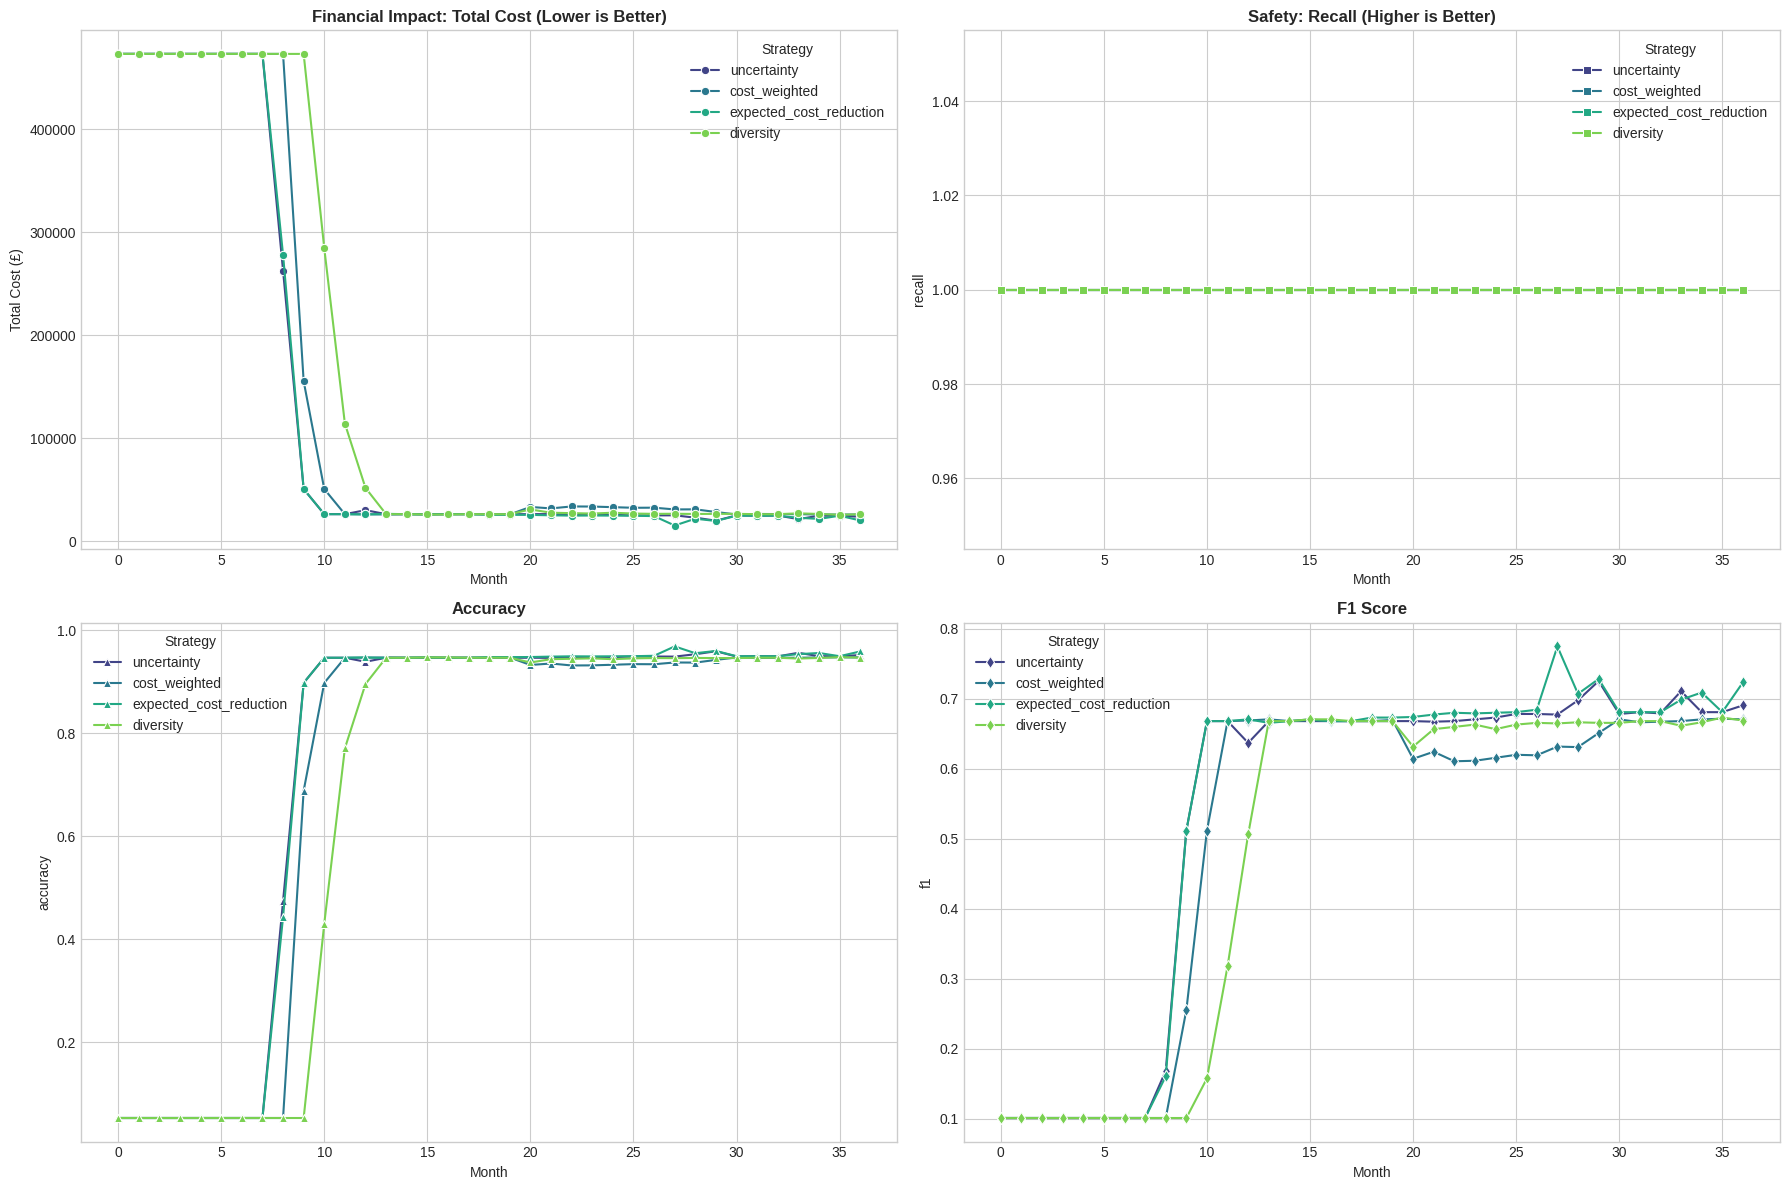


Final Results (Month 12):
expected_cost_reduction   | Cost: £26,200 | Recall: 100.00% | F1: 0.6709
cost_weighted             | Cost: £26,400 | Recall: 100.00% | F1: 0.6692
uncertainty               | Cost: £30,400 | Recall: 100.00% | F1: 0.6372
diversity                 | Cost: £52,000 | Recall: 100.00% | F1: 0.5066


In [ ]:
# =============================================================================
# 1. SETUP & DATA LOADING
# =============================================================================
import zipfile
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier
from sklearn.cluster import MiniBatchKMeans
from sklearn.metrics import accuracy_score, f1_score
import warnings

warnings.filterwarnings('ignore')  # Clean output

# ---- PATHS ----
ZIP_PATH = "/content/data_5L_new.zip"
EXTRACT_DIR = "/content/extracted_zip"

# ---- UNZIP & LOAD ----
if not os.path.exists(EXTRACT_DIR):
    with zipfile.ZipFile(ZIP_PATH, 'r') as z:
        z.extractall(EXTRACT_DIR)

csv_file = None
for file in os.listdir(EXTRACT_DIR):
    if file.endswith(".csv"):
        csv_file = os.path.join(EXTRACT_DIR, file)
        break

if csv_file is None:
    raise FileNotFoundError("No CSV file found inside the ZIP.")

print("Loading dataset...")
df = pd.read_csv(csv_file)
print(f"Data loaded: {df.shape}")

# =============================================================================
# 2. BUSINESS LOGIC & COSTS
# =============================================================================

def calculate_costs(sum_insured, y_true, y_pred):
    """
    Calculates the actual business cost of the model's decisions.
    """
    costs = np.zeros(len(y_true))

    # FN Cost: We pay the claim (90% of sum insured)
    fn_mask = (y_true == 1) & (y_pred == 0)
    costs[fn_mask] = sum_insured[fn_mask] * 0.90

    # FP Cost: We pay the investigation fee (£100)
    fp_mask = (y_true == 0) & (y_pred == 1)
    costs[fp_mask] = 100

    return costs

def get_sample_weights(y, sum_insured):
    """
    CRITICAL FIX: Create weights so the model 'feels' the cost during training.
    - If it's Fraud: Weight = Potential Payout (High importance)
    - If it's Legit: Weight = Investigation Fee (Lower importance)
    """
    weights = np.zeros(len(y))
    # Weight for FRAUD = Cost of missing it
    weights[y == 1] = sum_insured[y == 1] * 0.90
    # Weight for LEGIT = Cost of investigating it falsely
    weights[y == 0] = 100

    # Normalize weights to prevent numerical instability in XGBoost
    # We keep the RATIO (which is what matters), but scale numbers down
    weights = weights / weights.mean()
    return weights

def analyze_fraud_rules(df):
    print(f"\n{'='*20} FRAUD RULE INITIALIZATION {'='*20}")
    claim_ratio = df['sum_insured'] / (df['premium_with_tax'] + 1)

    rules = {
        "1. High Claim Ratio & No Prev Ins": (claim_ratio > 1500) & (df['previous_insurance_buildings'] == 0) & (df['no_of_claims_5yr'] > 0),
        "2. Accidental Dmg & Unoccupied": (df['accidental_damage_premium'] > 0) & (df['unoccupied_days'] >= 30) & (df['no_of_claims_5yr'] > 0),
        "3. Frequent Claims (3+)": (df['no_of_claims_5yr'] >= 3),
        "4. Business Use & Unoccupied": (df['unoccupied_days'] >= 30) & (df['business_use'] == 'Y') & (df['no_of_claims_5yr'] > 0),
    }

    combined_flags = pd.Series(False, index=df.index)
    for name, mask in rules.items():
        print(f"{name.ljust(45)}: {mask.sum():5d} flagged")
        combined_flags |= mask

    print(f"{'-'*60}")
    print(f"Total Initial Fraud Seeds: {combined_flags.sum()}")
    print(f"{'='*60}\n")
    return combined_flags

def prepare_features(df):
    categorical_cols = ['cust_occupation', 'owner_details', 'property_type',
                        'construction_material', 'roof_material', 'urban_rural', 'policy_product', 'business_use']
    df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)
    exclude_cols = ['fraud_label', 'fraud_probability', 'policy_no', 'unoccupied_reason']
    feature_cols = [col for col in df_encoded.columns if col not in exclude_cols]
    return df_encoded[feature_cols]

def evaluate_metrics(y_true, y_pred, sum_insured):
    costs = calculate_costs(sum_insured, y_true, y_pred)
    tp = np.sum((y_true == 1) & (y_pred == 1))
    fn = np.sum((y_true == 1) & (y_pred == 0))

    return {
        'total_cost': np.sum(costs),
        'recall': tp / (tp + fn) if (tp + fn) > 0 else 0,
        'accuracy': accuracy_score(y_true, y_pred),
        'f1': f1_score(y_true, y_pred)
    }

def find_optimal_threshold(model, X, y, sum_insured):
    """
    Finds the probability threshold that minimizes TOTAL COST (not just error).
    """
    proba = model.predict_proba(X)[:, 1]
    thresholds = np.linspace(0.01, 0.99, 100) # Scan more granularly
    best_cost = float('inf')
    best_thresh = 0.5

    for thresh in thresholds:
        y_pred = (proba >= thresh).astype(int)
        cost = np.sum(calculate_costs(sum_insured, y, y_pred))
        if cost < best_cost:
            best_cost = cost
            best_thresh = thresh
    return best_thresh

# =============================================================================
# 3. COST-AWARE ACTIVE LEARNING AGENT
# =============================================================================

class ActiveLearningAgent:
    def __init__(self):
        # Removed scale_pos_weight=5 because we are now using Sample Weights
        # which is a much more precise way to handle imbalance and cost.
        self.model = XGBClassifier(
            n_estimators=100, max_depth=5, learning_rate=0.1,
            random_state=42, eval_metric='logloss', n_jobs=-1
        )
        self.scaler = StandardScaler()
        self.threshold = 0.5
        self.labeled_data = {'X': None, 'y': None, 'sum_insured': None}
        self.feature_names = None

    def _align(self, df_input):
        X_feat = prepare_features(df_input.copy())
        for col in self.feature_names:
            if col not in X_feat.columns: X_feat[col] = 0
        return X_feat[self.feature_names].values

    def train_model(self):
        # 1. Get Data
        X = self.labeled_data['X']
        y = self.labeled_data['y']
        s = self.labeled_data['sum_insured']

        # 2. Calculate Cost-Based Weights
        # This forces the model to care 1000x more about high-value fraud
        sample_weights = get_sample_weights(y, s)

        # 3. Fit with Weights
        self.model.fit(X, y, sample_weight=sample_weights)

        # 4. Tune Threshold
        self.threshold = find_optimal_threshold(self.model, X, y, s)

    def initial_train(self, df_universe, flagged_indices):
        investigated = df_universe.loc[flagged_indices]
        X_df = prepare_features(investigated.copy())
        self.feature_names = X_df.columns.tolist()

        X_raw = X_df.values
        X_scaled = self.scaler.fit_transform(X_raw)

        self.labeled_data = {
            'X': X_scaled,
            'y': investigated['fraud_label'].values,
            'sum_insured': investigated['sum_insured'].values
        }
        self.train_model()

    def query(self, df_pool, budget, strategy):
        X_pool = self._align(df_pool)
        X_scaled = self.scaler.transform(X_pool)
        y_proba = self.model.predict_proba(X_scaled)[:, 1]
        sum_insured = df_pool['sum_insured'].values
        indices = df_pool.index.tolist()

        if strategy == 'uncertainty':
            scores = np.abs(y_proba - 0.5)
            # Lowest score = closest to 0.5 = most uncertain
            selected_idx = [indices[i] for i in np.argsort(scores)[:budget]]

        elif strategy == 'cost_weighted':
            uncertainty = 1 - np.abs(y_proba - 0.5) # High when uncertain
            # Normalize cost to 0-1 range for combining
            norm_cost = sum_insured / (np.max(sum_insured) + 1)
            # Combine: We want Uncertain AND Expensive items
            scores = uncertainty * norm_cost
            selected_idx = [indices[i] for i in np.argsort(scores)[::-1][:budget]]

        elif strategy == 'expected_cost_reduction':
            # Calculate Risk (Expected Loss)
            # Risk = (Prob of Fraud * Cost of Missing) + (Prob of Legit * Cost of Checking)
            risk_if_0 = y_proba * (sum_insured * 0.90)
            risk_if_1 = (1 - y_proba) * 100

            # Select items where the model is currently making the "Riskiest" decision
            current_decision = (y_proba >= self.threshold).astype(int)
            current_risk = np.where(current_decision == 0, risk_if_0, risk_if_1)

            selected_idx = [indices[i] for i in np.argsort(current_risk)[::-1][:budget]]

        elif strategy == 'diversity':
            # Standard diversity strategy
            n_clusters = max(5, budget // 2)
            kmeans = MiniBatchKMeans(n_clusters=n_clusters, random_state=42, batch_size=256)
            cluster_labels = kmeans.fit_predict(X_scaled)
            dists = np.min(kmeans.transform(X_scaled), axis=1)

            pool_data = pd.DataFrame({'idx': indices, 'cluster': cluster_labels, 'prob': y_proba, 'dist': dists})
            pool_data['score'] = (1 - np.abs(2 * pool_data['prob'] - 1)) + (0.5 * pool_data['dist']) # Uncertainty + Dist

            selected_idx = []
            groups = pool_data.groupby('cluster')
            sorted_groups = {k: v.sort_values('score', ascending=False) for k, v in groups}
            active = list(sorted_groups.keys())

            while len(selected_idx) < budget and active:
                for c in list(active):
                    if len(selected_idx) >= budget: break
                    if not sorted_groups[c].empty:
                        selected_idx.append(sorted_groups[c].iloc[0]['idx'])
                        sorted_groups[c] = sorted_groups[c].iloc[1:]
                    else:
                        active.remove(c)

        return selected_idx

    def retrain(self, df_universe, new_indices):
        new_data = df_universe.loc[new_indices]
        X_new = self.scaler.transform(self._align(new_data))
        y_new = new_data['fraud_label'].values
        s_new = new_data['sum_insured'].values

        self.labeled_data['X'] = np.vstack([self.labeled_data['X'], X_new])
        self.labeled_data['y'] = np.concatenate([self.labeled_data['y'], y_new])
        self.labeled_data['sum_insured'] = np.concatenate([self.labeled_data['sum_insured'], s_new])

        self.train_model()

    def evaluate(self, df_test):
        X_test = self.scaler.transform(self._align(df_test))
        y_test = df_test['fraud_label'].values
        s_test = df_test['sum_insured'].values
        y_pred = (self.model.predict_proba(X_test)[:, 1] >= self.threshold).astype(int)
        return evaluate_metrics(y_test, y_pred, s_test)

# =============================================================================
# 4. SIMULATION LOOP
# =============================================================================

def run_comparison(df, strategies, n_months=12, monthly_vol=1000, budget=150):
    # Setup Data
    initial_pool = df.sample(n=10000, random_state=42)
    flags = analyze_fraud_rules(initial_pool)
    flagged_idx = initial_pool[flags].index

    # Test Set (Must be separate to judge generalization)
    avail_after_init = df.drop(index=initial_pool.index)
    test_set = avail_after_init.sample(n=5000, random_state=999)
    base_used_indices = set(initial_pool.index) | set(test_set.index)

    all_results = []

    for strat in strategies:
        print(f"Running Strategy: {strat.upper()}...")

        agent = ActiveLearningAgent()
        agent.initial_train(df, flagged_idx)
        current_used_indices = base_used_indices.copy()

        # Month 0 (Baseline)
        m = agent.evaluate(test_set)
        all_results.append({'Strategy': strat, 'Month': 0, **m})

        for month in range(1, n_months + 1):
            # New Data Stream
            available = df.drop(index=current_used_indices)
            if len(available) < monthly_vol: break
            new_batch = available.sample(n=monthly_vol, random_state=month)
            current_used_indices.update(new_batch.index)

            # Active Learning Step
            query_idx = agent.query(new_batch, budget, strat)
            agent.retrain(df, query_idx)

            # Evaluate
            m = agent.evaluate(test_set)
            all_results.append({'Strategy': strat, 'Month': month, **m})

    return pd.DataFrame(all_results)

# =============================================================================
# 5. EXECUTION & PLOTTING
# =============================================================================

STRATEGIES = ['uncertainty', 'cost_weighted', 'expected_cost_reduction', 'diversity']

df_results = run_comparison(df, STRATEGIES, n_months=36, monthly_vol=1000, budget=150)

# ---- PLOT ----
plt.style.use('seaborn-v0_8-whitegrid')
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# 1. Cost (Goal: Decrease)
sns.lineplot(data=df_results, x='Month', y='total_cost', hue='Strategy', marker='o', ax=axes[0,0], palette='viridis')
axes[0,0].set_title('Financial Impact: Total Cost (Lower is Better)', fontweight='bold')
axes[0,0].set_ylabel('Total Cost (£)')

# 2. Recall (Goal: Increase)
sns.lineplot(data=df_results, x='Month', y='recall', hue='Strategy', marker='s', ax=axes[0,1], palette='viridis')
axes[0,1].set_title('Safety: Recall (Higher is Better)', fontweight='bold')

# 3. Accuracy
sns.lineplot(data=df_results, x='Month', y='accuracy', hue='Strategy', marker='^', ax=axes[1,0], palette='viridis')
axes[1,0].set_title('Accuracy', fontweight='bold')

# 4. F1 Score
sns.lineplot(data=df_results, x='Month', y='f1', hue='Strategy', marker='d', ax=axes[1,1], palette='viridis')
axes[1,1].set_title('F1 Score', fontweight='bold')

plt.tight_layout()
plt.show()

# ---- FINAL STATS ----
print("\nFinal Results (Month 12):")
final_df = df_results[df_results['Month'] == 12].sort_values('total_cost')
for _, row in final_df.iterrows():
    print(f"{row['Strategy'].ljust(25)} | Cost: £{row['total_cost']:,.0f} | Recall: {row['recall']:.2%} | F1: {row['f1']:.4f}")